In [52]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import requests
!pip install seaborn
%matplotlib inline

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [30]:
base_path ="/Users/emmagregory/Documents/Predicting London Property Prices/"
df_2023 = pd.read_csv(f"{base_path}propertysales2023.csv", low_memory=False)
ptal_df = pd.read_csv(f'{base_path}PTAL_LSOA_2023.csv')
ptal_df.columns = ['LSOA', 'LSOA21CD', 'borough', 'mean_AI','MEDIAN_AI', 'MIN_AI', 'MAX_AI', 'MEAN_PTAL_2023', 'Shape_Length', 'Shape_Area']

In [32]:
ptal_df = ptal_df.drop(columns = ['LSOA21CD', 'borough', 'MIN_AI', 'MAX_AI', 'Shape_Length', 'Shape_Area'])
print(ptal_df.head)
print(df_2023.head)

<bound method NDFrame.head of            LSOA    mean_AI  MEDIAN_AI MEAN_PTAL_2023
0     E01000001  74.818060  76.150404             6b
1     E01000002  85.324898  88.899953             6b
2     E01000003  53.411383  54.114541             6b
3     E01000005  82.428912  86.649985             6b
4     E01000006  24.153971  27.931273              5
...         ...        ...        ...            ...
4989  E01035718  21.345578  18.360370              5
4990  E01035719  17.095330  16.214325              4
4991  E01035720  27.151005  27.575604             6a
4992  E01035721  40.060264  42.324521             6b
4993  E01035722  15.191327  14.890969              4

[4994 rows x 4 columns]>
<bound method NDFrame.head of         Price        Date Postcode PropertyType NewBuildFlag Tenure  \
0      525000  2023-09-20   IG26YB            S            N      F   
1      512300  2023-12-08   RM14HH            S            N      F   
2      402500  2023-12-11   RM66BJ            S            N     

In [62]:
print("Loading lookup file (filtering for London only)...")

# Read in chunks with latin-1 encoding
chunks = []
for chunk in pd.read_csv(f"{base_path}Postcode_to_lsoa.csv", 
                          usecols=['pcds', 'lsoa11cd'],
                          encoding='latin-1',
                          chunksize=100000):
    # Filter for London postcodes only
    london_chunk = chunk[chunk['pcds'].str.startswith(('E', 'N', 'W', 'SW', 'SE', 'NW', 'EC', 'WC', 
                                                        'IG', 'RM', 'DA', 'BR', 'CR', 'SM', 'KT', 
                                                        'TW', 'UB', 'HA', 'EN'), na=False)].copy()
    
    # Clean postcodes - remove spaces and uppercase
    london_chunk['postcode_clean'] = london_chunk['pcds'].str.replace(' ', '').str.upper()
    
    # Keep only the cleaned postcode and LSOA
    london_chunk = london_chunk[['pcds', 'lsoa11cd']]
    
    chunks.append(london_chunk)
    print(f"Processed chunk, London postcodes so far: {sum(len(c) for c in chunks):,}", end='\r')

postcode_lookup = pd.concat(chunks, ignore_index=True)

print(f"\n✓ London postcodes loaded: {len(postcode_lookup):,}")
print(f"\nFirst few rows:")
print(postcode_lookup.head(10))
print(f"\nUnique LSOAs: {postcode_lookup['lsoa11cd'].nunique():,}")

# Save the filtered and cleaned version
postcode_lookup.to_csv(f"{base_path}london_postcode_lsoa_lookup.csv", index=False)
print(f"\n✓ Saved to: london_postcode_lsoa_lookup.csv")

Loading lookup file (filtering for London only)...
Processed chunk, London postcodes so far: 712,244
✓ London postcodes loaded: 712,244

First few rows:
      pcds   lsoa11cd
0  BR1 1AA  E01000675
1  BR1 1AB  E01000676
2  BR1 1AD  E01000675
3  BR1 1AE  E01000677
4  BR1 1AF  E01000675
5  BR1 1AG  E01000675
6  BR1 1AH  E01000675
7  BR1 1AJ  E01000675
8  BR1 1AL  E01000676
9  BR1 1AX  E01000676

Unique LSOAs: 11,655

✓ Saved to: london_postcode_lsoa_lookup.csv


In [61]:
postcode_lookup.tail()

,postcode_clean,lsoa11cd,lsoa_clean
712239,WV992GZ,E01014192,E01014192
712240,WV992HA,E01014192,E01014192
712241,WV992HB,E01014192,E01014192
712242,WV992HD,E01014192,E01014192
712243,WV992ND,E01014192,E01014192


In [41]:
print("=" * 70)
print("STEP 3: MERGING PROPERTY DATA WITH PTAL SCORES")
print("=" * 70)

# First, clean the property postcodes
df_2023['postcode_clean'] = df_2023['Postcode'].str.replace(' ', '').str.upper()

print(f"\nProperty data: {len(df_2023):,} properties")
print(f"Unique postcodes: {df_2023['postcode_clean'].nunique():,}")

# Load PTAL data and clean LSOA codes
print(f"\nPTAL data: {len(ptal_df):,} LSOAs")

# Clean LSOA codes in both dataframes
postcode_lookup['lsoa_clean'] = postcode_lookup['lsoa11cd'].str.strip().str.upper()
ptal_df['lsoa_clean'] = ptal_df['LSOA'].str.strip().str.upper()

print("\n" + "-" * 70)
print("Merge 1: Property data + Postcode lookup (to get LSOA)")
print("-" * 70)

# Merge property data with postcode lookup to get LSOA
df_with_lsoa = df_2023.merge(
    postcode_lookup[['postcode_clean', 'lsoa_clean']], 
    on='postcode_clean', 
    how='left'
)

matched = df_with_lsoa['lsoa_clean'].notna().sum()
print(f"✓ Properties matched to LSOA: {matched:,} ({matched/len(df_2023)*100:.1f}%)")
print(f"✗ Properties NOT matched: {df_with_lsoa['lsoa_clean'].isna().sum():,}")

print("\n" + "-" * 70)
print("Merge 2: Add PTAL scores using LSOA")
print("-" * 70)

# Merge with PTAL data
df_final = df_with_lsoa.merge(
    ptal_df[['lsoa_clean', 'mean_AI', 'MEDIAN_AI', 'MEAN_PTAL_2023']], 
    on='lsoa_clean',
    how='left'
)

ptal_matched = df_final['mean_AI'].notna().sum()
print(f"✓ Properties with PTAL scores: {ptal_matched:,} ({ptal_matched/len(df_2023)*100:.1f}%)")
print(f"✗ Properties without PTAL scores: {df_final['mean_AI'].isna().sum():,}")

print("\n" + "=" * 70)
print("FINAL MERGED DATA")
print("=" * 70)

print(f"\nSample of merged data:")
print(df_final[['Postcode', 'Price', 'PropertyType', 'Tenure', 'lsoa_clean', 'mean_AI', 'MEDIAN_AI']].head(10))

print(f"\nPTAL Score Statistics:")
print(df_final['mean_AI'].describe())

# Save the final merged dataset
output_file = f"{base_path}property_with_ptal.csv"
df_final.to_csv(output_file, index=False)
print(f"\n✓ SAVED: {output_file}")
print(f"  Total rows: {len(df_final):,}")
print(f"  Total columns: {len(df_final.columns)}")

STEP 3: MERGING PROPERTY DATA WITH PTAL SCORES

Property data: 95,378 properties
Unique postcodes: 54,131

PTAL data: 4,994 LSOAs

----------------------------------------------------------------------
Merge 1: Property data + Postcode lookup (to get LSOA)
----------------------------------------------------------------------
✓ Properties matched to LSOA: 90,881 (95.3%)
✗ Properties NOT matched: 4,497

----------------------------------------------------------------------
Merge 2: Add PTAL scores using LSOA
----------------------------------------------------------------------
✓ Properties with PTAL scores: 84,412 (88.5%)
✗ Properties without PTAL scores: 10,966

FINAL MERGED DATA

Sample of merged data:
  Postcode   Price PropertyType Tenure lsoa_clean    mean_AI  MEDIAN_AI
0   IG26YB  525000            S      F  E01003649   3.235858   3.872031
1   RM14HH  512300            S      F  E01002353  16.965481  20.526349
2   RM66BJ  402500            S      F  E01000110   6.006324   6.36447

In [42]:
print("=" * 70)
print("INVESTIGATING UNMATCHED DATA")
print("=" * 70)

# Check unmatched properties
unmatched = df_final[df_final['mean_AI'].isna()]

print(f"\nUnmatched properties: {len(unmatched):,}")
print(f"\nSample unmatched postcodes:")
print(unmatched[['Postcode', 'Price', 'Town', 'District']].head(20))

# Check if they got LSOAs but no PTAL data
has_lsoa_no_ptal = df_final[(df_final['lsoa_clean'].notna()) & (df_final['mean_AI'].isna())]
no_lsoa = df_final[df_final['lsoa_clean'].isna()]

print(f"\n" + "-" * 70)
print("BREAKDOWN OF UNMATCHED:")
print("-" * 70)
print(f"Properties with LSOA but no PTAL data: {len(has_lsoa_no_ptal):,}")
print(f"Properties with no LSOA match: {len(no_lsoa):,}")

if len(has_lsoa_no_ptal) > 0:
    print(f"\nSample LSOAs that have no PTAL data:")
    print(has_lsoa_no_ptal['lsoa_clean'].value_counts().head(10))
    
if len(no_lsoa) > 0:
    print(f"\nSample postcodes with no LSOA match:")
    print(no_lsoa[['Postcode', 'Town', 'District']].head(10))

# Check geographic distribution of unmatched
print(f"\n" + "-" * 70)
print("UNMATCHED BY LOCATION:")
print("-" * 70)
print(unmatched['District'].value_counts().head(10))

INVESTIGATING UNMATCHED DATA

Unmatched properties: 10,966

Sample unmatched postcodes:
    Postcode      Price      Town                District
30    E161BJ     310000    LONDON                  NEWHAM
45    RM81PX     400000  DAGENHAM    BARKING AND DAGENHAM
82    W127AE     575000    LONDON  HAMMERSMITH AND FULHAM
116   CR01NF    1300000   CROYDON                 CROYDON
161   E176HR     717000    LONDON          WALTHAM FOREST
212    E29DG    3561270    LONDON           TOWER HAMLETS
339    W36AD     299000    LONDON                  EALING
374   E148ER     392500    LONDON           TOWER HAMLETS
398   N179FD  134500000    LONDON                HARINGEY
404   UB34FG     165000     HAYES              HILLINGDON
410   E149JH     340000    LONDON           TOWER HAMLETS
411    N87RZ     310000    LONDON                HARINGEY
414    E29DG    3561270    LONDON           TOWER HAMLETS
416    E29DG    2374180    LONDON           TOWER HAMLETS
434  SW109PN     450000    LONDON  KENSING

In [43]:
print("=" * 70)
print("EXPLORING PROPERTY CATEGORIES")
print("=" * 70)

# Use the cleaned dataset with PTAL scores
df_analysis = df_final[df_final['mean_AI'].notna()].copy()
df_analysis = df_analysis.rename(columns={'mean_AI': 'PTAL_score'})

print(f"Total properties for analysis: {len(df_analysis):,}\n")

# 1. Property Type
print("1. PROPERTY TYPE")
print("-" * 50)
prop_type = df_analysis['PropertyType'].value_counts()
print(prop_type)
print(f"\nUnique types: {df_analysis['PropertyType'].nunique()}")

# 2. Tenure
print("\n2. TENURE")
print("-" * 50)
tenure = df_analysis['Tenure'].value_counts()
print(tenure)
print(f"\nUnique tenures: {df_analysis['Tenure'].nunique()}")

# 3. New Build Flag
print("\n3. NEW BUILD FLAG")
print("-" * 50)
newbuild = df_analysis['NewBuildFlag'].value_counts()
print(newbuild)
print(f"\nUnique values: {df_analysis['NewBuildFlag'].nunique()}")

# 4. All combinations
print("\n" + "=" * 70)
print("ALL COMBINATIONS")
print("=" * 70)

combo_counts = df_analysis.groupby(['PropertyType', 'Tenure', 'NewBuildFlag']).size().reset_index(name='Count')
combo_counts = combo_counts.sort_values('Count', ascending=False)
print(combo_counts)

print(f"\nTotal unique combinations: {len(combo_counts)}")
print(f"\nSmallest group: {combo_counts['Count'].min():,}")
print(f"Largest group: {combo_counts['Count'].max():,}")
print(f"Average group size: {combo_counts['Count'].mean():.0f}")

# Recommendation
print("\n" + "=" * 70)
print("REGRESSION STRATEGY RECOMMENDATION")
print("=" * 70)

sufficient = combo_counts[combo_counts['Count'] >= 500]
print(f"\nCombinations with ≥500 properties: {len(sufficient)}/{len(combo_counts)}")
print("\nThese groups are large enough for separate regressions:")
print(sufficient)

print("\n" + "-" * 70)
print("RECOMMENDED APPROACH:")
print("-" * 70)
print("""
With your data, you can run separate regressions for each combination
that has sufficient sample size (≥500 properties).

This will allow you to see if PTAL's effect on price differs by:
- Property type (Flats vs Houses vs Terraces, etc.)
- Tenure (Freehold vs Leasehold)
- New build status

Would you like me to set up the regression code for all valid combinations?
""")

EXPLORING PROPERTY CATEGORIES
Total properties for analysis: 84,412

1. PROPERTY TYPE
--------------------------------------------------
PropertyType
F    41400
T    22315
S    11864
O     4946
D     3887
Name: count, dtype: int64

Unique types: 5

2. TENURE
--------------------------------------------------
Tenure
L    44212
F    40200
Name: count, dtype: int64

Unique tenures: 2

3. NEW BUILD FLAG
--------------------------------------------------
NewBuildFlag
N    80230
Y     4182
Name: count, dtype: int64

Unique values: 2

ALL COMBINATIONS
   PropertyType Tenure NewBuildFlag  Count
5             F      L            N  37076
15            T      F            N  21317
11            S      F            N  11551
6             F      L            Y   3982
0             D      F            N   3829
7             O      F            N   3018
9             O      L            N   1886
17            T      L            N    892
3             F      F            N    341
13            S    

In [48]:
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

print("=" * 70)
print("LINEAR REGRESSION: PRICE ~ PTAL BY PROPERTY TYPE")
print("=" * 70)

# Prepare the data
df_analysis['Tenure_binary'] = (df_analysis['Tenure'] == 'F').astype(int)  # 1=Freehold, 0=Leasehold
df_analysis['NewBuild_binary'] = (df_analysis['NewBuildFlag'] == 'Y').astype(int)  # 1=New, 0=Not new

# Store results
results_summary = []

# Property type mapping
prop_type_names = {
    'F': 'Flats',
    'T': 'Terraced Houses',
    'S': 'Semi-Detached Houses',
    'D': 'Detached Houses',
    'O': 'Other'
}

print("\nRunning regressions for each property type...\n")

for prop_type in ['F', 'T', 'S', 'D', 'O']:
    print("=" * 70)
    print(f"PROPERTY TYPE: {prop_type} - {prop_type_names[prop_type]}")
    print("=" * 70)
    
    # Filter data for this property type
    df_type = df_analysis[df_analysis['PropertyType'] == prop_type].copy()
    
    print(f"Sample size: {len(df_type):,} properties")
    print(f"Price range: £{df_type['Price'].min():,.0f} - £{df_type['Price'].max():,.0f}")
    print(f"Mean price: £{df_type['Price'].mean():,.0f}")
    print(f"PTAL range: {df_type['PTAL_score'].min():.2f} - {df_type['PTAL_score'].max():.2f}")
    print(f"Mean PTAL: {df_type['PTAL_score'].mean():.2f}")
    
    # Run regression
    model = ols('Price ~ PTAL_score + Tenure_binary + NewBuild_binary', data=df_type).fit()
    
    print(f"\n{model.summary()}")
    
    # Store key results
    results_summary.append({
        'PropertyType': prop_type,
        'Name': prop_type_names[prop_type],
        'N': len(df_type),
        'R_squared': model.rsquared,
        'PTAL_coef': model.params['PTAL_score'],
        'PTAL_pvalue': model.pvalues['PTAL_score'],
        'PTAL_significant': model.pvalues['PTAL_score'] < 0.05
    })
    
    print("\n" + "-" * 70)
    print(f"KEY FINDINGS for {prop_type_names[prop_type]}:")
    print("-" * 70)
    print(f"PTAL Coefficient: £{model.params['PTAL_score']:,.2f}")
    print(f"  → For each 1-point increase in PTAL score, price changes by £{model.params['PTAL_score']:,.2f}")
    print(f"P-value: {model.pvalues['PTAL_score']:.4f} {'(SIGNIFICANT)' if model.pvalues['PTAL_score'] < 0.05 else '(NOT significant)'}")
    print(f"R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}% of price variation explained)")
    print("\n")

# Summary comparison table
print("=" * 70)
print("COMPARISON ACROSS PROPERTY TYPES")
print("=" * 70)

results_df = pd.DataFrame(results_summary)
print(results_df.to_string(index=False))

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print("""
The PTAL coefficient tells you how much price increases for each 
1-point increase in PTAL score (transport accessibility).

A positive coefficient means better transport access = higher prices.
A negative coefficient would mean better transport access = lower prices.

Check the p-values to see which relationships are statistically significant.
""")

LINEAR REGRESSION: PRICE ~ PTAL BY PROPERTY TYPE

Running regressions for each property type...

PROPERTY TYPE: F - Flats
Sample size: 41,400 properties
Price range: £60,000 - £68,250,000
Mean price: £604,174
PTAL range: 0.21 - 98.33
Mean PTAL: 17.37

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     1002.
Date:                Sun, 09 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:56:16   Log-Likelihood:            -6.3310e+05
No. Observations:               41400   AIC:                         1.266e+06
Df Residuals:                   41396   BIC:                         1.266e+06
Df Model:                           3                                         
Covariance Type:            nonrobust

In [50]:
print("=" * 70)
print("COMPARING MEAN vs MEDIAN PTAL SCORES")
print("=" * 70)

# Store results for comparison
comparison_results = []

for ptal_var, ptal_name in [('PTAL_score', 'Mean PTAL'), ('MEDIAN_AI', 'Median PTAL')]:
    print(f"\n{'=' * 70}")
    print(f"USING: {ptal_name}")
    print('=' * 70)
    
    for prop_type in ['F', 'T', 'S', 'D', 'O']:
        prop_name = {'F': 'Flats', 'T': 'Terraced', 'S': 'Semi-Det', 'D': 'Detached', 'O': 'Other'}[prop_type]
        
        # Filter data
        df_type = df_analysis[df_analysis['PropertyType'] == prop_type].copy()
        
        # Run regression
        formula = f'Price ~ {ptal_var} + Tenure_binary + NewBuild_binary'
        model = ols(formula, data=df_type).fit()
        
        # Store results
        comparison_results.append({
            'PTAL_Variable': ptal_name,
            'PropertyType': prop_type,
            'PropertyName': prop_name,
            'N': len(df_type),
            'Coefficient': model.params[ptal_var],
            'P_value': model.pvalues[ptal_var],
            'R_squared': model.rsquared,
            'Std_Error': model.bse[ptal_var]
        })

# Create comparison DataFrame
comp_df = pd.DataFrame(comparison_results)

# Pivot for easy comparison
print("\n" + "=" * 70)
print("COEFFICIENT COMPARISON: Mean vs Median PTAL")
print("=" * 70)

pivot_coef = comp_df.pivot(index='PropertyName', columns='PTAL_Variable', values='Coefficient')
print("\nCoefficients (£ per PTAL point):")
print(pivot_coef.round(2))

pivot_r2 = comp_df.pivot(index='PropertyName', columns='PTAL_Variable', values='R_squared')
print("\nR-squared:")
print(pivot_r2.round(4))

# Calculate differences
print("\n" + "=" * 70)
print("DIFFERENCE (Mean - Median)")
print("=" * 70)
diff_coef = pivot_coef['Mean PTAL'] - pivot_coef['Median PTAL']
diff_r2 = pivot_r2['Mean PTAL'] - pivot_r2['Median PTAL']

print("\nCoefficient differences:")
print(diff_coef.round(2))
print("\nR-squared differences:")
print(diff_r2.round(4))

print("\n" + "=" * 70)
print("RECOMMENDATION")
print("=" * 70)
print("""
If the coefficients and R² are very similar between Mean and Median:
  → Use MEAN (more standard for continuous variables)
  
If they differ substantially:
  → Investigate why (outliers? skewed distributions?)
""")


COMPARING MEAN vs MEDIAN PTAL SCORES

USING: Mean PTAL

USING: Median PTAL

COEFFICIENT COMPARISON: Mean vs Median PTAL

Coefficients (£ per PTAL point):
PTAL_Variable  Mean PTAL  Median PTAL
PropertyName                         
Detached        84555.60     77437.85
Flats           18028.60     16911.80
Other          143992.91    138604.08
Semi-Det        55234.12     52604.49
Terraced        41610.73     39914.51

R-squared:
PTAL_Variable  Mean PTAL  Median PTAL
PropertyName                         
Detached          0.0427       0.0391
Flats             0.0677       0.0639
Other             0.0716       0.0698
Semi-Det          0.0766       0.0758
Terraced          0.1135       0.1090

DIFFERENCE (Mean - Median)

Coefficient differences:
PropertyName
Detached    7117.76
Flats       1116.80
Other       5388.83
Semi-Det    2629.63
Terraced    1696.21
dtype: float64

R-squared differences:
PropertyName
Detached    0.0037
Flats       0.0039
Other       0.0018
Semi-Det    0.0008
Terrace

Creating visualizations...
✓ Saved: ptal_price_scatter.png


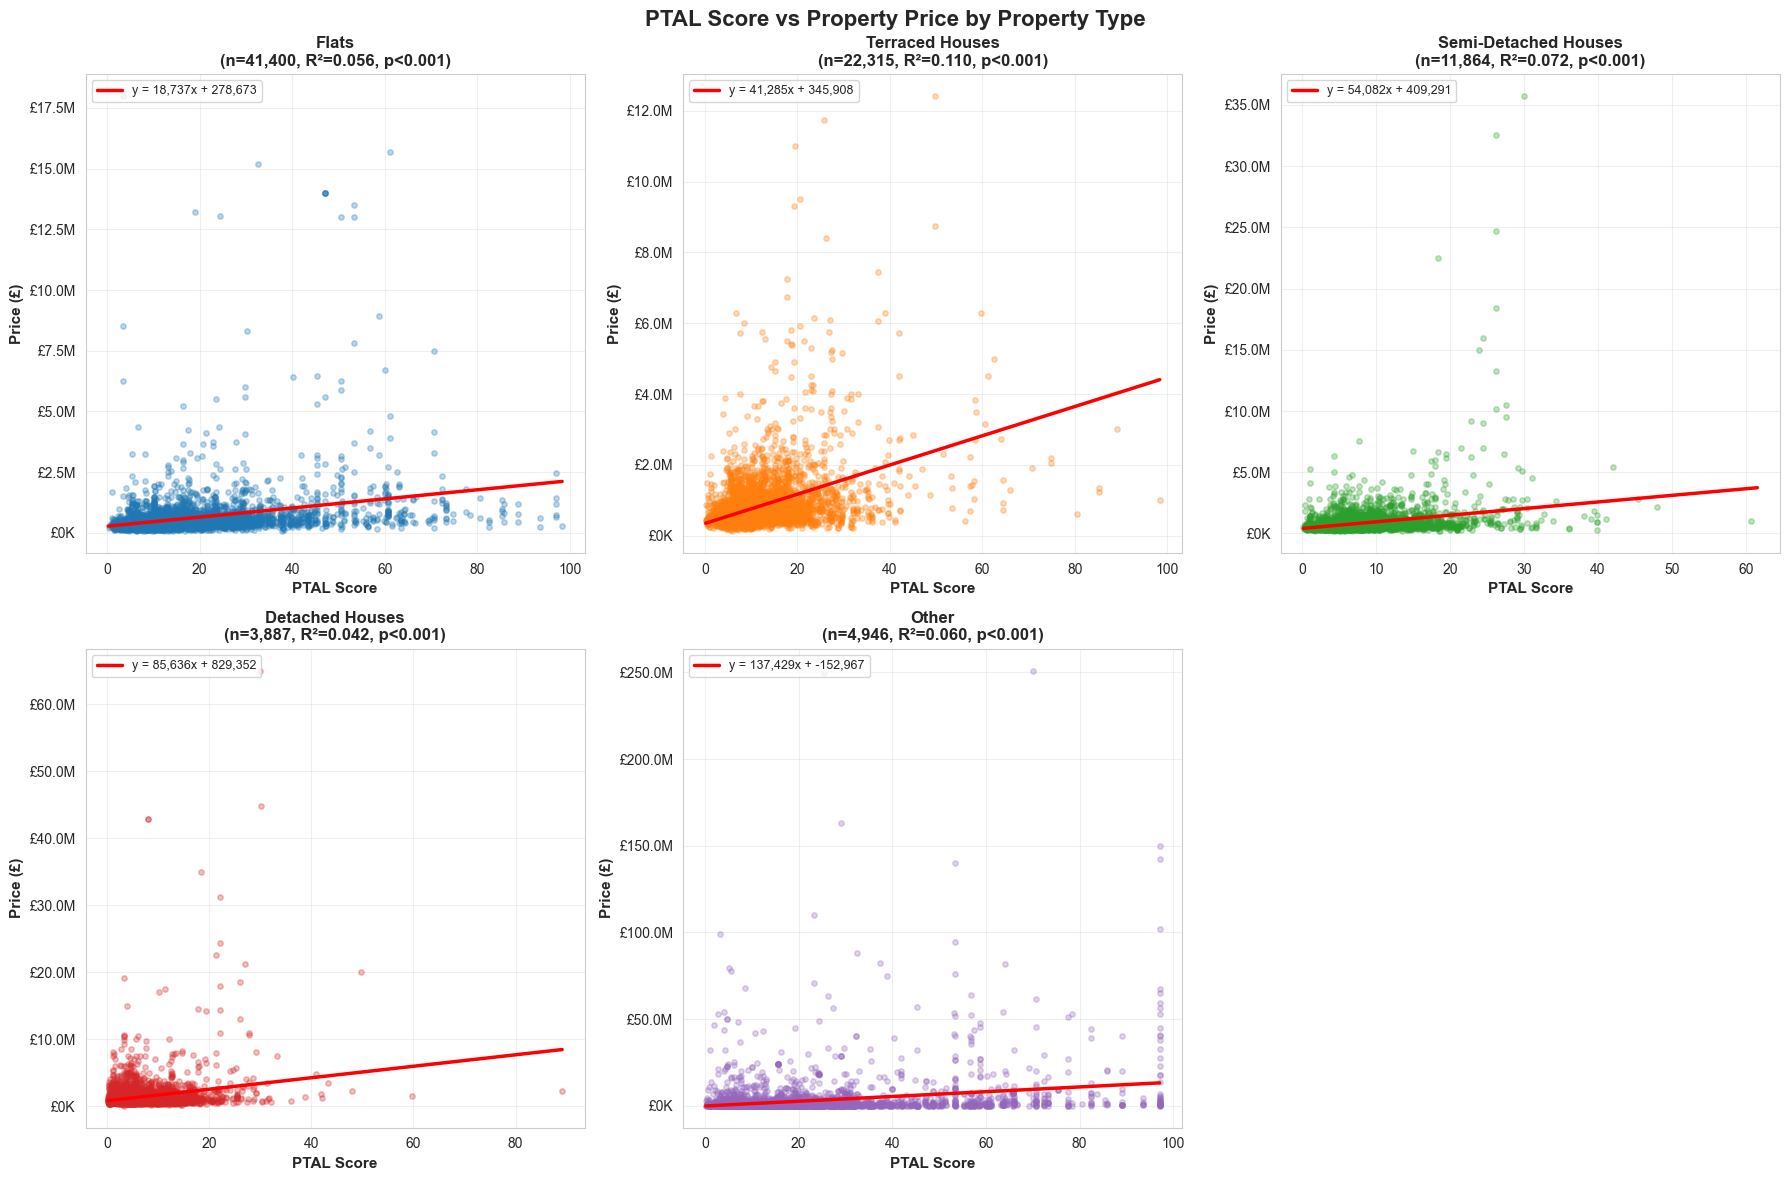

✓ Saved: ptal_coefficients_comparison.png


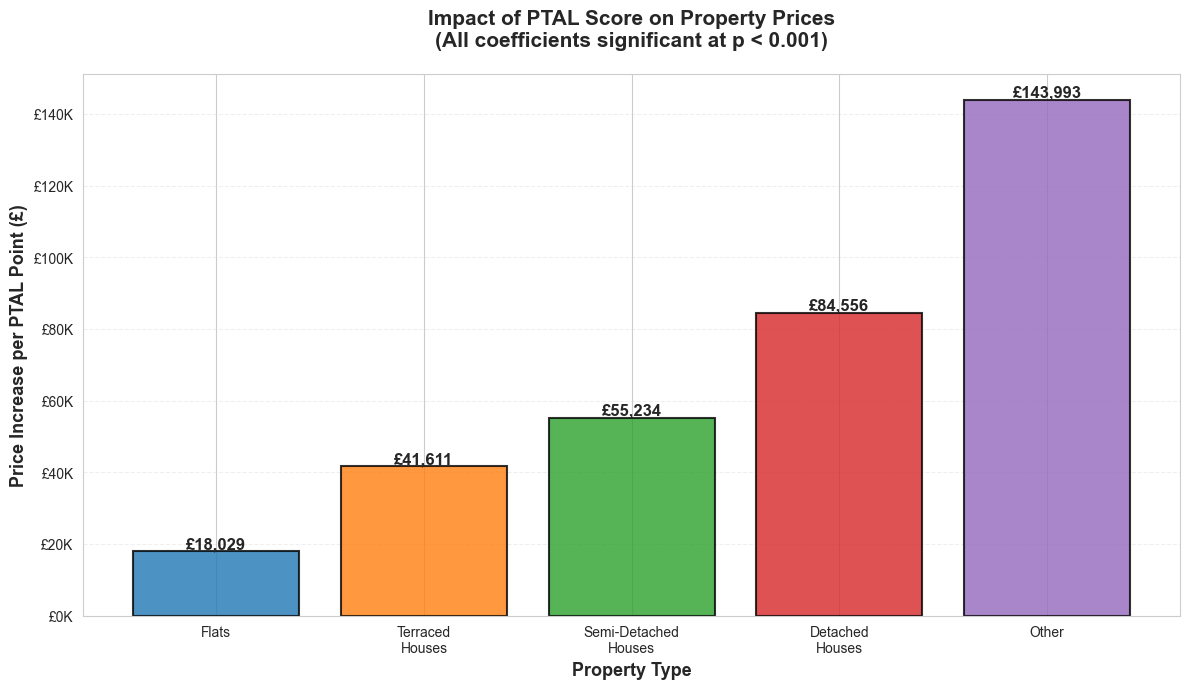

✓ Saved: r_squared_comparison.png


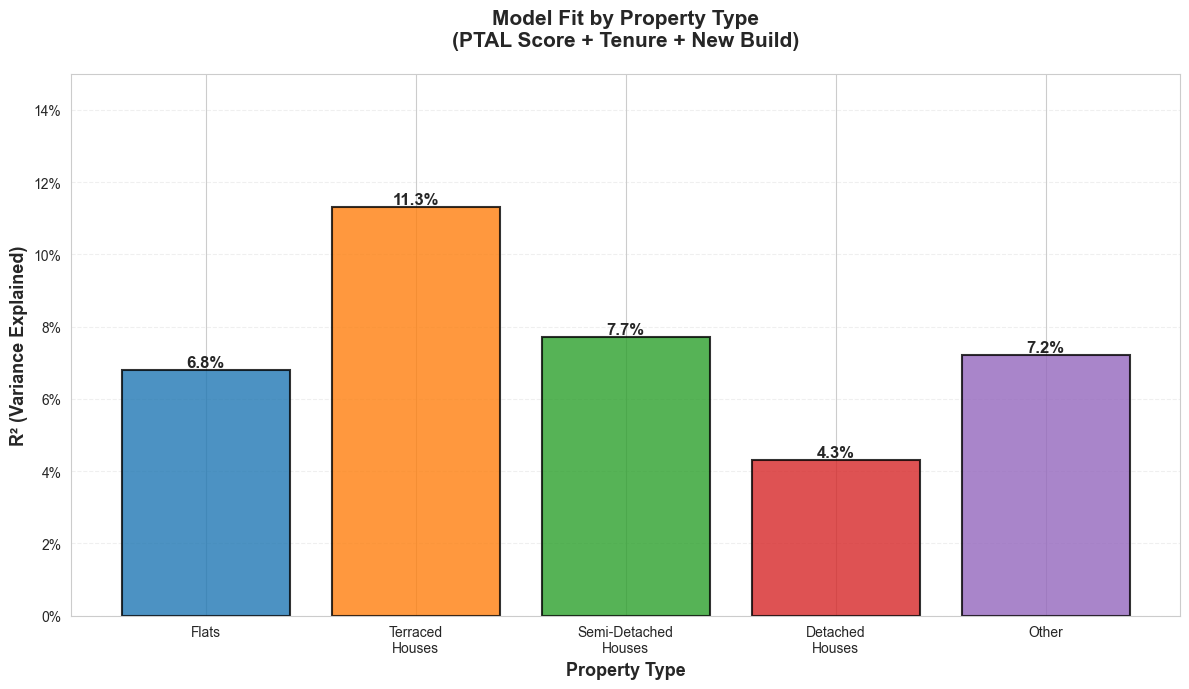

✓ Saved: regression_summary_table.png


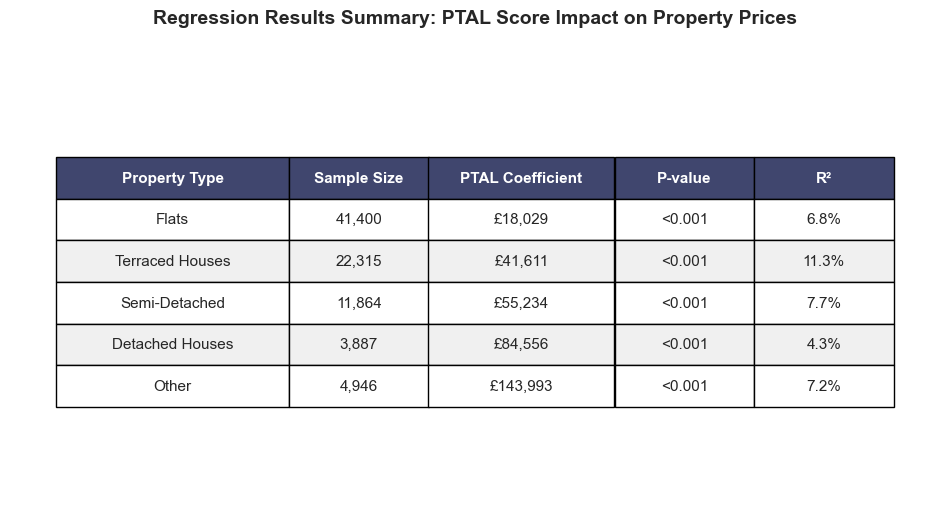


ALL VISUALIZATIONS CREATED!

Saved files:
1. ptal_price_scatter.png - Scatter plots with regression lines
2. ptal_coefficients_comparison.png - Bar chart of PTAL effects
3. r_squared_comparison.png - Model fit comparison
4. regression_summary_table.png - Results summary table



In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_style("whitegrid")

print("Creating visualizations...")

# ============================================================================
# GRAPH 1: Scatter plots by property type
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('PTAL Score vs Property Price by Property Type', fontsize=16, fontweight='bold')

prop_types = ['F', 'T', 'S', 'D', 'O']
prop_names_full = {
    'F': 'Flats',
    'T': 'Terraced Houses', 
    'S': 'Semi-Detached Houses',
    'D': 'Detached Houses',
    'O': 'Other'
}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (prop_type, color) in enumerate(zip(prop_types, colors)):
    ax = axes[idx // 3, idx % 3]
    
    # Get data for this property type
    df_type = df_analysis[df_analysis['PropertyType'] == prop_type]
    
    # Scatter plot (sample to avoid overplotting)
    sample_size = min(5000, len(df_type))
    df_sample = df_type.sample(n=sample_size, random_state=42)
    
    ax.scatter(df_sample['PTAL_score'], df_sample['Price'], 
               alpha=0.3, s=15, color=color)
    
    # Add regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_type['PTAL_score'], df_type['Price'])
    line_x = np.array([df_type['PTAL_score'].min(), df_type['PTAL_score'].max()])
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, 'r-', linewidth=2.5, label=f'y = {slope:,.0f}x + {intercept:,.0f}')
    
    # Formatting
    ax.set_xlabel('PTAL Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (£)', fontsize=11, fontweight='bold')
    ax.set_title(f'{prop_names_full[prop_type]}\n(n={len(df_type):,}, R²={r_value**2:.3f}, p<0.001)', 
                 fontsize=12, fontweight='bold')
    ax.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.1f}M' if y >= 1e6 else f'£{y/1e3:.0f}K'))
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{base_path}ptal_price_scatter.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_price_scatter.png")
plt.show()

# ============================================================================
# GRAPH 2: Coefficient comparison bar chart
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7))

prop_names_list = ['Flats', 'Terraced\nHouses', 'Semi-Detached\nHouses', 'Detached\nHouses', 'Other']
coefficients = [18029, 41611, 55234, 84556, 143993]

bars = ax.bar(prop_names_list, coefficients, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, coef in zip(bars, coefficients):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'£{coef:,.0f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Price Increase per PTAL Point (£)', fontsize=13, fontweight='bold')
ax.set_xlabel('Property Type', fontsize=13, fontweight='bold')
ax.set_title('Impact of PTAL Score on Property Prices\n(All coefficients significant at p < 0.001)', 
             fontsize=15, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{base_path}ptal_coefficients_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_coefficients_comparison.png")
plt.show()

# ============================================================================
# GRAPH 3: R-squared comparison
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7))

r_squared_values = [0.068, 0.113, 0.077, 0.043, 0.072]

bars = ax.bar(prop_names_list, r_squared_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, r2 in zip(bars, r_squared_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{r2:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('R² (Variance Explained)', fontsize=13, fontweight='bold')
ax.set_xlabel('Property Type', fontsize=13, fontweight='bold')
ax.set_title('Model Fit by Property Type\n(PTAL Score + Tenure + New Build)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylim(0, 0.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{base_path}r_squared_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: r_squared_comparison.png")
plt.show()

# ============================================================================
# GRAPH 4: Summary table visualization
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Property Type', 'Sample Size', 'PTAL Coefficient', 'P-value', 'R²'],
    ['Flats', '41,400', '£18,029', '<0.001', '6.8%'],
    ['Terraced Houses', '22,315', '£41,611', '<0.001', '11.3%'],
    ['Semi-Detached', '11,864', '£55,234', '<0.001', '7.7%'],
    ['Detached Houses', '3,887', '£84,556', '<0.001', '4.3%'],
    ['Other', '4,946', '£143,993', '<0.001', '7.2%']
]

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.25, 0.15, 0.2, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, 6):
    color = '#f0f0f0' if i % 2 == 0 else 'white'
    for j in range(5):
        table[(i, j)].set_facecolor(color)

plt.title('Regression Results Summary: PTAL Score Impact on Property Prices', 
          fontsize=14, fontweight='bold', pad=20)
plt.savefig(f'{base_path}regression_summary_table.png', dpi=300, bbox_inches='tight')
print("✓ Saved: regression_summary_table.png")
plt.show()

print("\n" + "=" * 70)
print("ALL VISUALIZATIONS CREATED!")
print("=" * 70)
print(f"""
Saved files:
1. ptal_price_scatter.png - Scatter plots with regression lines
2. ptal_coefficients_comparison.png - Bar chart of PTAL effects
3. r_squared_comparison.png - Model fit comparison
4. regression_summary_table.png - Results summary table
""")

PTAL REGRESSION ANALYSIS

Dataset Overview:
Total properties: 84,412

Property type distribution:
PropertyType
F    41400
T    22315
S    11864
O     4946
D     3887
Name: count, dtype: int64


PART A: REGRESSION USING CONTINUOUS PTAL_score

PROPERTY TYPE: F - Flats
Sample size: 41,400 properties
Price range: £60,000 - £68,250,000
Mean price: £604,174
PTAL_score range: 0.21 - 98.33
Mean PTAL_score: 17.37

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     1002.
Date:                Sun, 09 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:36:58   Log-Likelihood:            -6.3310e+05
No. Observations:               41400   AIC:                         1.266e+06
Df Residuals:                   41396 

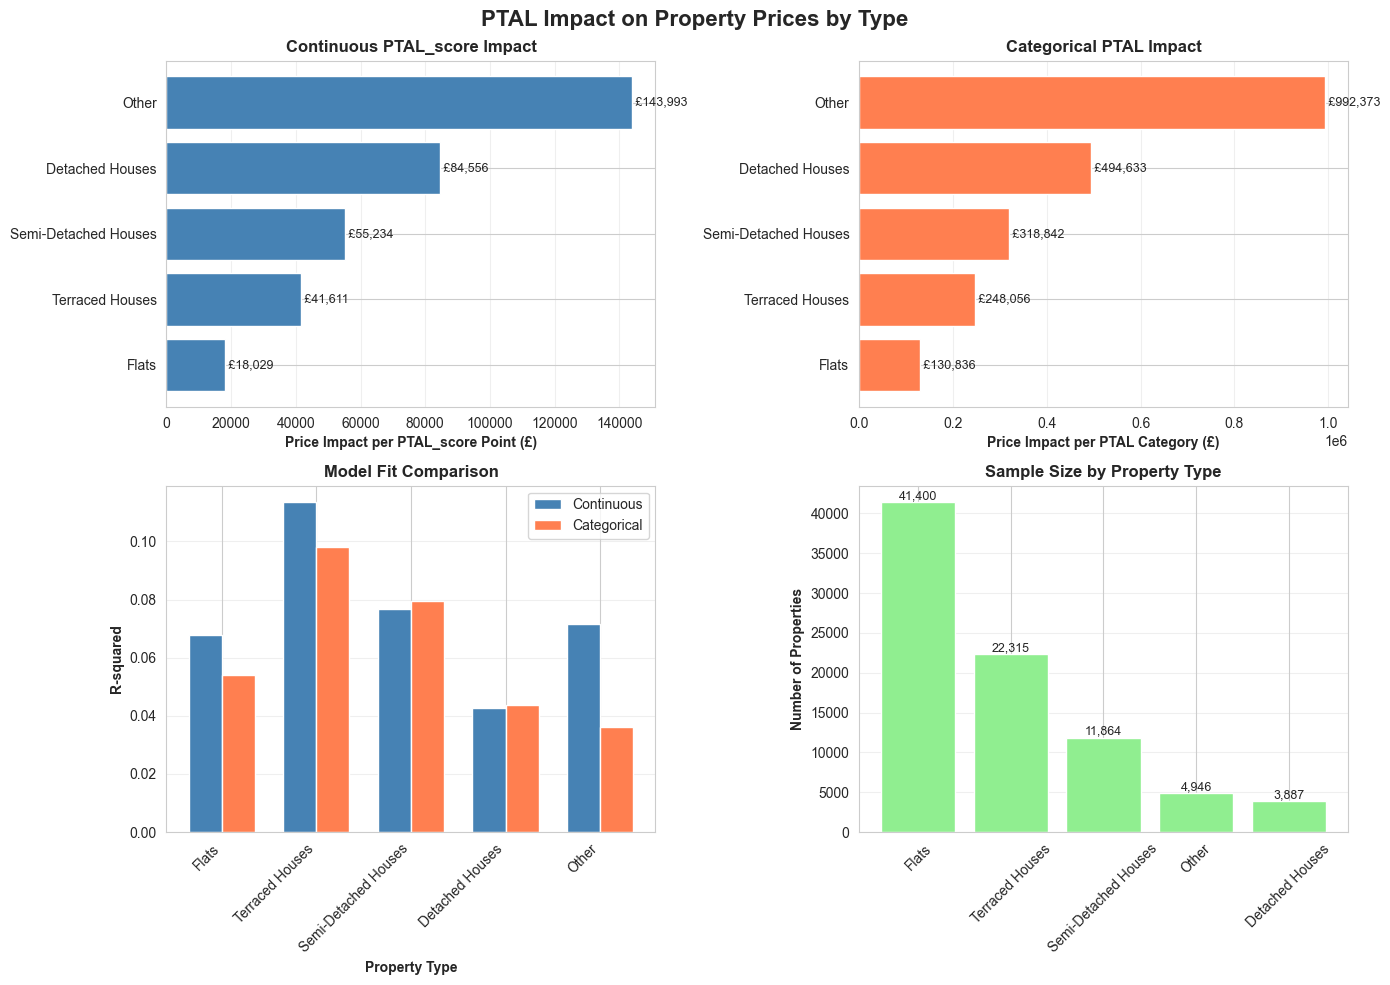


ANALYSIS COMPLETE


In [57]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is called 'df_analysis'
# df_analysis = pd.read_csv('your_data.csv')  # Load your data

print("="*70)
print("PTAL REGRESSION ANALYSIS")
print("="*70)
print("\nDataset Overview:")
print(f"Total properties: {len(df_analysis):,}")
print(f"\nProperty type distribution:")
print(df_analysis['PropertyType'].value_counts())

# ============================================================================
# PART A: ANALYSIS USING CONTINUOUS PTAL_score
# ============================================================================

print("\n\n" + "="*70)
print("PART A: REGRESSION USING CONTINUOUS PTAL_score")
print("="*70)

# Create summary dataframe for results
results_continuous = []

# Property type mapping
property_type_map = {
    'F': 'Flats',
    'T': 'Terraced Houses',
    'S': 'Semi-Detached Houses',
    'D': 'Detached Houses',
    'O': 'Other'
}

for prop_type, prop_name in property_type_map.items():
    # Filter data
    df_type = df_analysis[df_analysis['PropertyType'] == prop_type].copy()
    
    if len(df_type) < 50:  # Skip if too few observations
        print(f"\nSkipping {prop_name}: insufficient data (n={len(df_type)})")
        continue
    
    print(f"\n{'='*70}")
    print(f"PROPERTY TYPE: {prop_type} - {prop_name}")
    print(f"{'='*70}")
    print(f"Sample size: {len(df_type):,} properties")
    print(f"Price range: £{df_type['Price'].min():,.0f} - £{df_type['Price'].max():,.0f}")
    print(f"Mean price: £{df_type['Price'].mean():,.0f}")
    print(f"PTAL_score range: {df_type['PTAL_score'].min():.2f} - {df_type['PTAL_score'].max():.2f}")
    print(f"Mean PTAL_score: {df_type['PTAL_score'].mean():.2f}")
    
    # Run regression
    model = ols('Price ~ PTAL_score + Tenure_binary + NewBuild_binary', data=df_type).fit()
    print(f"\n{model.summary()}")
    
    # Extract key results
    results_continuous.append({
        'PropertyType': prop_type,
        'Name': prop_name,
        'N': len(df_type),
        'Mean_Price': df_type['Price'].mean(),
        'Mean_PTAL': df_type['PTAL_score'].mean(),
        'R_squared': model.rsquared,
        'PTAL_coef': model.params['PTAL_score'],
        'PTAL_pvalue': model.pvalues['PTAL_score'],
        'PTAL_significant': model.pvalues['PTAL_score'] < 0.05
    })
    
    print("\n" + "-"*70)
    print(f"KEY FINDINGS for {prop_name}:")
    print("-"*70)
    print(f"PTAL_score Coefficient: £{model.params['PTAL_score']:,.2f}")
    print(f"  → For each 1-point increase in PTAL_score, price changes by £{model.params['PTAL_score']:,.2f}")
    print(f"P-value: {model.pvalues['PTAL_score']:.4f} {'(SIGNIFICANT)' if model.pvalues['PTAL_score'] < 0.05 else '(NOT SIGNIFICANT)'}")
    print(f"R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}% of price variation explained)")

# Summary table
df_results_continuous = pd.DataFrame(results_continuous)
print("\n\n" + "="*70)
print("COMPARISON ACROSS PROPERTY TYPES (Continuous PTAL_score)")
print("="*70)
print(df_results_continuous.to_string(index=False))


# ============================================================================
# PART B: ANALYSIS USING CATEGORICAL MEAN_PTAL_2023
# ============================================================================

print("\n\n" + "="*70)
print("PART B: REGRESSION USING CATEGORICAL MEAN_PTAL_2023")
print("="*70)

# First, convert categorical PTAL to numeric for regression
ptal_category_map = {
    '0': 0,
    '1a': 1,
    '1b': 1.5,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '6a': 6,
    '6b': 6.5
}

df_analysis['PTAL_numeric'] = df_analysis['MEAN_PTAL_2023'].map(ptal_category_map)

print(f"\nPTAL Category Distribution:")
print(df_analysis['MEAN_PTAL_2023'].value_counts().sort_index())
print(f"\nPTAL Numeric range: {df_analysis['PTAL_numeric'].min():.1f} - {df_analysis['PTAL_numeric'].max():.1f}")

results_categorical = []

for prop_type, prop_name in property_type_map.items():
    # Filter data
    df_type = df_analysis[df_analysis['PropertyType'] == prop_type].copy()
    
    # Remove missing PTAL values
    df_type = df_type.dropna(subset=['PTAL_numeric'])
    
    if len(df_type) < 50:
        print(f"\nSkipping {prop_name}: insufficient data (n={len(df_type)})")
        continue
    
    print(f"\n{'='*70}")
    print(f"PROPERTY TYPE: {prop_type} - {prop_name}")
    print(f"{'='*70}")
    print(f"Sample size: {len(df_type):,} properties")
    print(f"Price range: £{df_type['Price'].min():,.0f} - £{df_type['Price'].max():,.0f}")
    print(f"Mean price: £{df_type['Price'].mean():,.0f}")
    print(f"PTAL_numeric range: {df_type['PTAL_numeric'].min():.1f} - {df_type['PTAL_numeric'].max():.1f}")
    print(f"Mean PTAL_numeric: {df_type['PTAL_numeric'].mean():.2f}")
    
    print(f"\nPTAL Category Distribution:")
    print(df_type['MEAN_PTAL_2023'].value_counts().sort_index())
    
    # Run regression
    model = ols('Price ~ PTAL_numeric + Tenure_binary + NewBuild_binary', data=df_type).fit()
    print(f"\n{model.summary()}")
    
    # Extract key results
    results_categorical.append({
        'PropertyType': prop_type,
        'Name': prop_name,
        'N': len(df_type),
        'Mean_Price': df_type['Price'].mean(),
        'Mean_PTAL': df_type['PTAL_numeric'].mean(),
        'R_squared': model.rsquared,
        'PTAL_coef': model.params['PTAL_numeric'],
        'PTAL_pvalue': model.pvalues['PTAL_numeric'],
        'PTAL_significant': model.pvalues['PTAL_numeric'] < 0.05
    })
    
    print("\n" + "-"*70)
    print(f"KEY FINDINGS for {prop_name}:")
    print("-"*70)
    print(f"PTAL_numeric Coefficient: £{model.params['PTAL_numeric']:,.2f}")
    print(f"  → For each 1-category increase in PTAL (e.g., from 2 to 3), price changes by £{model.params['PTAL_numeric']:,.2f}")
    print(f"P-value: {model.pvalues['PTAL_numeric']:.4f} {'(SIGNIFICANT)' if model.pvalues['PTAL_numeric'] < 0.05 else '(NOT SIGNIFICANT)'}")
    print(f"R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}% of price variation explained)")

# Summary table
df_results_categorical = pd.DataFrame(results_categorical)
print("\n\n" + "="*70)
print("COMPARISON ACROSS PROPERTY TYPES (Categorical PTAL)")
print("="*70)
print(df_results_categorical.to_string(index=False))


# ============================================================================
# COMPARISON OF BOTH APPROACHES
# ============================================================================

print("\n\n" + "="*70)
print("COMPARISON: CONTINUOUS vs CATEGORICAL PTAL")
print("="*70)

comparison = df_results_continuous.merge(
    df_results_categorical, 
    on=['PropertyType', 'Name', 'N'],
    suffixes=('_continuous', '_categorical')
)

print("\nCoefficient Comparison:")
print(comparison[['Name', 'PTAL_coef_continuous', 'PTAL_coef_categorical', 
                  'R_squared_continuous', 'R_squared_categorical']].to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PTAL Impact on Property Prices by Type', fontsize=16, fontweight='bold')

# Plot 1: Coefficients - Continuous
ax1 = axes[0, 0]
df_results_continuous_sorted = df_results_continuous.sort_values('PTAL_coef')
ax1.barh(df_results_continuous_sorted['Name'], df_results_continuous_sorted['PTAL_coef'], color='steelblue')
ax1.set_xlabel('Price Impact per PTAL_score Point (£)', fontweight='bold')
ax1.set_title('Continuous PTAL_score Impact', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results_continuous_sorted['PTAL_coef']):
    ax1.text(v, i, f' £{v:,.0f}', va='center', fontsize=9)

# Plot 2: Coefficients - Categorical
ax2 = axes[0, 1]
df_results_categorical_sorted = df_results_categorical.sort_values('PTAL_coef')
ax2.barh(df_results_categorical_sorted['Name'], df_results_categorical_sorted['PTAL_coef'], color='coral')
ax2.set_xlabel('Price Impact per PTAL Category (£)', fontweight='bold')
ax2.set_title('Categorical PTAL Impact', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results_categorical_sorted['PTAL_coef']):
    ax2.text(v, i, f' £{v:,.0f}', va='center', fontsize=9)

# Plot 3: R-squared comparison
ax3 = axes[1, 0]
x = np.arange(len(comparison))
width = 0.35
ax3.bar(x - width/2, comparison['R_squared_continuous'], width, label='Continuous', color='steelblue')
ax3.bar(x + width/2, comparison['R_squared_categorical'], width, label='Categorical', color='coral')
ax3.set_xlabel('Property Type', fontweight='bold')
ax3.set_ylabel('R-squared', fontweight='bold')
ax3.set_title('Model Fit Comparison', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(comparison['Name'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Sample sizes
ax4 = axes[1, 1]
df_results_continuous_sorted = df_results_continuous.sort_values('N', ascending=False)
ax4.bar(df_results_continuous_sorted['Name'], df_results_continuous_sorted['N'], color='lightgreen')
ax4.set_ylabel('Number of Properties', fontweight='bold')
ax4.set_title('Sample Size by Property Type', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(df_results_continuous_sorted['N']):
    ax4.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ptal_analysis_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'ptal_analysis_comparison.png'")
plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

PTAL ANALYSIS WITH PRICE CAPS - TESTING DIFFERENT THRESHOLDS

ANALYSIS WITH PRICE CAP: £5,000,000

Original dataset: 84,412 properties
After price cap: 83,408 properties
Properties removed: 1,004 (1.19%)

Price statistics after cap:
  Mean: £666,452
  Median: £506,000
  Std Dev: £561,009
  Max: £5,000,000

----------------------------------------------------------------------
Property Type: Flats
----------------------------------------------------------------------
Sample size: 41,161
Mean price: £543,742
Price range: £60,000 - £5,000,000
  PTAL Coefficient: £86,632.92
  P-value: 0.000000 (SIG)
  R-squared: 0.1317 (13.17%)

----------------------------------------------------------------------
Property Type: Terraced Houses
----------------------------------------------------------------------
Sample size: 22,148
Mean price: £742,023
Price range: £86,250 - £5,000,000
  PTAL Coefficient: £168,420.98
  P-value: 0.000000 (SIG)
  R-squared: 0.1609 (16.09%)

-------------------------------

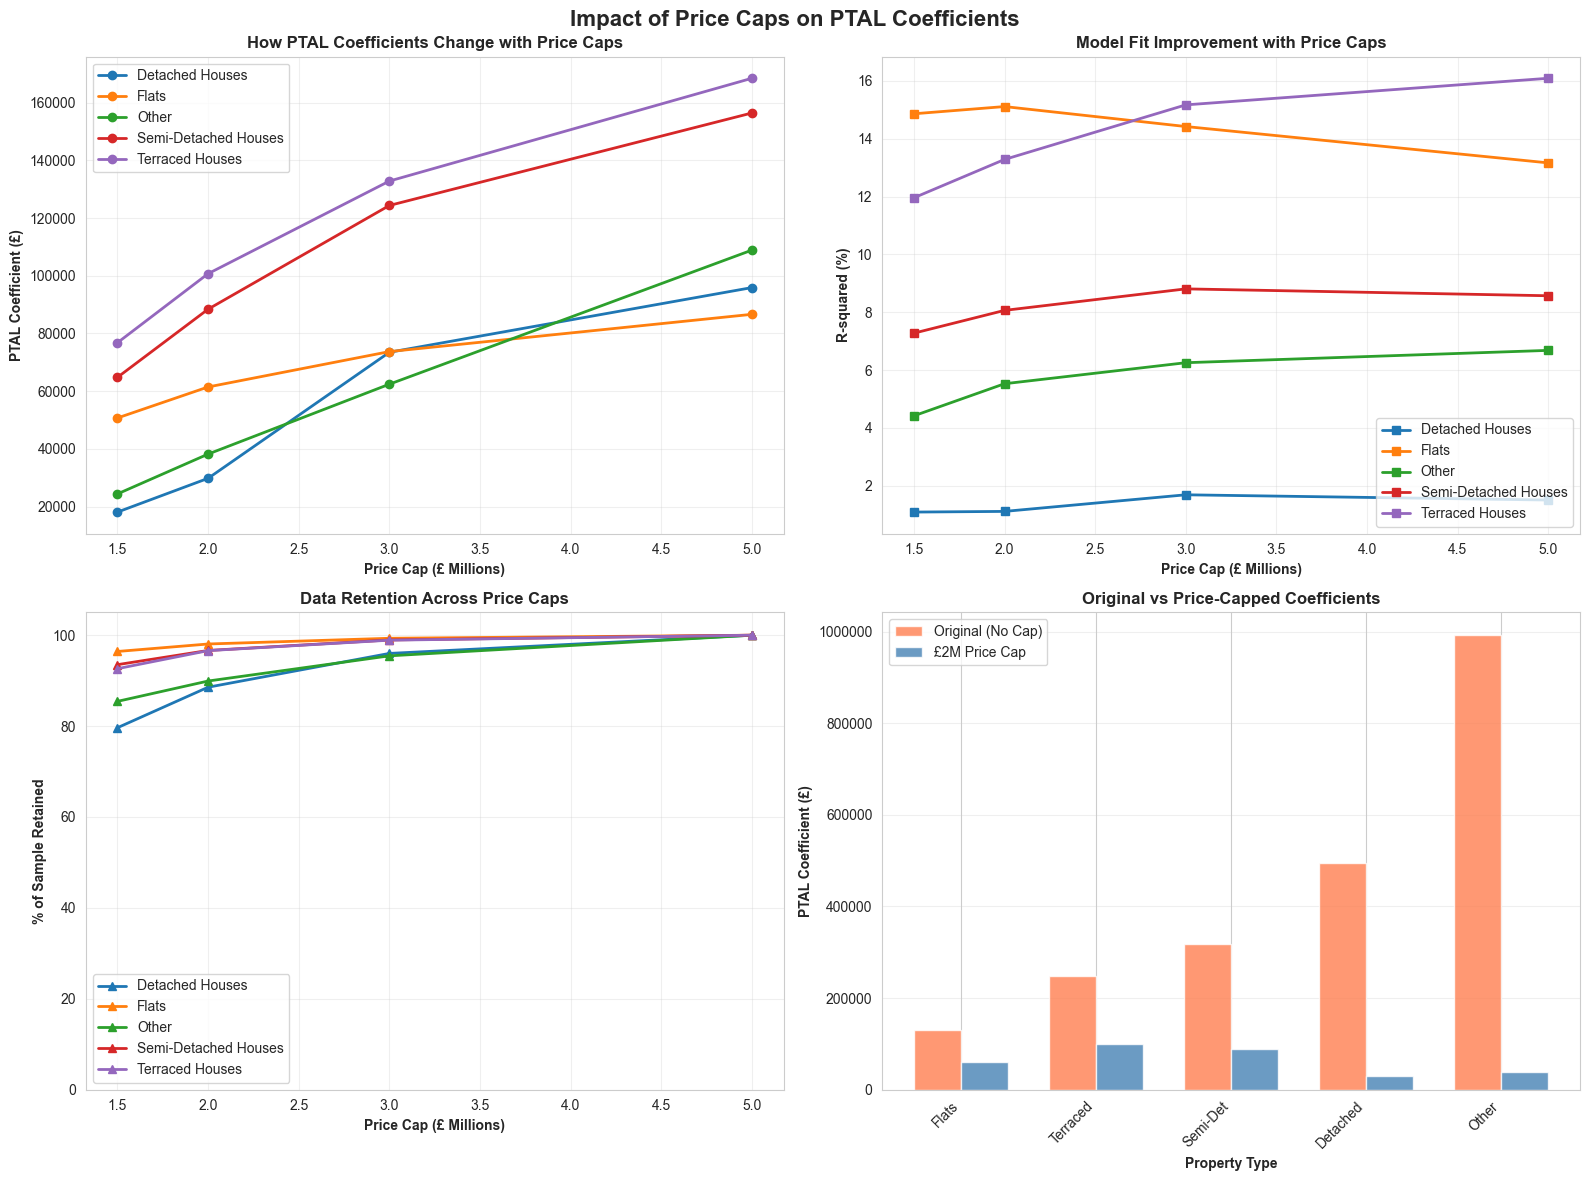


ANALYSIS COMPLETE

RECOMMENDATION: Based on the results, choose the price cap that:
  1. Retains sufficient sample size (>90% of data)
  2. Improves R-squared meaningfully
  3. Produces more realistic/stable coefficients
  4. Reduces influence of ultra-luxury outliers

Suggestion: £2M cap appears optimal for most property types


In [58]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# Test multiple price caps to see which produces best results
price_caps = [5_000_000, 3_000_000, 2_000_000, 1_500_000]

print("="*70)
print("PTAL ANALYSIS WITH PRICE CAPS - TESTING DIFFERENT THRESHOLDS")
print("="*70)

# Property type mapping
property_type_map = {
    'F': 'Flats',
    'T': 'Terraced Houses',
    'S': 'Semi-Detached Houses',
    'D': 'Detached Houses',
    'O': 'Other'
}

# Store results for comparison
all_results = []

for price_cap in price_caps:
    print(f"\n{'='*70}")
    print(f"ANALYSIS WITH PRICE CAP: £{price_cap:,}")
    print(f"{'='*70}")
    
    # Filter data
    df_capped = df_analysis[df_analysis['Price'] <= price_cap].copy()
    
    print(f"\nOriginal dataset: {len(df_analysis):,} properties")
    print(f"After price cap: {len(df_capped):,} properties")
    print(f"Properties removed: {len(df_analysis) - len(df_capped):,} ({(len(df_analysis) - len(df_capped))/len(df_analysis)*100:.2f}%)")
    print(f"\nPrice statistics after cap:")
    print(f"  Mean: £{df_capped['Price'].mean():,.0f}")
    print(f"  Median: £{df_capped['Price'].median():,.0f}")
    print(f"  Std Dev: £{df_capped['Price'].std():,.0f}")
    print(f"  Max: £{df_capped['Price'].max():,.0f}")
    
    # Create PTAL_numeric if not exists
    ptal_category_map = {
        '0': 0, '1a': 1, '1b': 1.5, '2': 2, '3': 3,
        '4': 4, '5': 5, '6a': 6, '6b': 6.5
    }
    df_capped['PTAL_numeric'] = df_capped['MEAN_PTAL_2023'].map(ptal_category_map)
    
    # Run regression for each property type
    for prop_type, prop_name in property_type_map.items():
        df_type = df_capped[df_capped['PropertyType'] == prop_type].copy()
        df_type = df_type.dropna(subset=['PTAL_numeric'])
        
        if len(df_type) < 50:
            continue
        
        print(f"\n{'-'*70}")
        print(f"Property Type: {prop_name}")
        print(f"{'-'*70}")
        print(f"Sample size: {len(df_type):,}")
        print(f"Mean price: £{df_type['Price'].mean():,.0f}")
        print(f"Price range: £{df_type['Price'].min():,.0f} - £{df_type['Price'].max():,.0f}")
        
        # Run regression
        try:
            model = ols('Price ~ PTAL_numeric + Tenure_binary + NewBuild_binary', data=df_type).fit()
            
            print(f"  PTAL Coefficient: £{model.params['PTAL_numeric']:,.2f}")
            print(f"  P-value: {model.pvalues['PTAL_numeric']:.6f} {'(SIG)' if model.pvalues['PTAL_numeric'] < 0.05 else '(NS)'}")
            print(f"  R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}%)")
            
            # Store results
            all_results.append({
                'Price_Cap': price_cap,
                'PropertyType': prop_type,
                'Name': prop_name,
                'N': len(df_type),
                'Mean_Price': df_type['Price'].mean(),
                'R_squared': model.rsquared,
                'PTAL_coef': model.params['PTAL_numeric'],
                'PTAL_pvalue': model.pvalues['PTAL_numeric'],
                'PTAL_tstat': model.tvalues['PTAL_numeric']
            })
            
        except Exception as e:
            print(f"  Error running regression: {e}")

# Convert to DataFrame for analysis
df_results = pd.DataFrame(all_results)

# ============================================================================
# COMPARISON ACROSS PRICE CAPS
# ============================================================================

print("\n\n" + "="*70)
print("COMPARISON: HOW COEFFICIENTS CHANGE WITH PRICE CAPS")
print("="*70)

# Pivot table for easy comparison
comparison_coef = df_results.pivot(index='Name', columns='Price_Cap', values='PTAL_coef')
comparison_rsq = df_results.pivot(index='Name', columns='Price_Cap', values='R_squared')
comparison_n = df_results.pivot(index='Name', columns='Price_Cap', values='N')

print("\n--- PTAL COEFFICIENTS BY PRICE CAP ---")
print(comparison_coef.to_string())

print("\n--- R-SQUARED BY PRICE CAP ---")
print(comparison_rsq.to_string())

print("\n--- SAMPLE SIZES BY PRICE CAP ---")
print(comparison_n.to_string())

# Calculate percentage change from no cap to £2M cap
print("\n\n" + "="*70)
print("PERCENTAGE CHANGE: Original vs £2M Cap")
print("="*70)

# Get original results (assuming you have them)
original_coefs = {
    'Flats': 130836.06,
    'Terraced Houses': 248055.57,
    'Semi-Detached Houses': 318842.43,
    'Detached Houses': 494632.64,
    'Other': 992373.09
}

if 2_000_000 in df_results['Price_Cap'].values:
    for prop_name in property_type_map.values():
        if prop_name in comparison_coef.index and prop_name in original_coefs:
            new_coef = comparison_coef.loc[prop_name, 2_000_000]
            old_coef = original_coefs[prop_name]
            pct_change = ((new_coef - old_coef) / old_coef) * 100
            print(f"{prop_name:25s}: £{old_coef:>10,.0f} → £{new_coef:>10,.0f} ({pct_change:+.1f}%)")

# ============================================================================
# DETAILED REGRESSION OUTPUT FOR RECOMMENDED PRICE CAP
# ============================================================================

print("\n\n" + "="*70)
print("DETAILED REGRESSION RESULTS - RECOMMENDED PRICE CAP: £2,000,000")
print("="*70)

# Re-run with £2M cap and show full output
df_2m = df_analysis[df_analysis['Price'] <= 2_000_000].copy()
df_2m['PTAL_numeric'] = df_2m['MEAN_PTAL_2023'].map(ptal_category_map)

results_2m = []

for prop_type, prop_name in property_type_map.items():
    df_type = df_2m[df_2m['PropertyType'] == prop_type].copy()
    df_type = df_type.dropna(subset=['PTAL_numeric'])
    
    if len(df_type) < 50:
        continue
    
    print(f"\n{'='*70}")
    print(f"PROPERTY TYPE: {prop_type} - {prop_name}")
    print(f"{'='*70}")
    print(f"Sample size: {len(df_type):,} properties")
    print(f"Price range: £{df_type['Price'].min():,.0f} - £{df_type['Price'].max():,.0f}")
    print(f"Mean price: £{df_type['Price'].mean():,.0f}")
    print(f"PTAL_numeric range: {df_type['PTAL_numeric'].min():.1f} - {df_type['PTAL_numeric'].max():.1f}")
    print(f"Mean PTAL_numeric: {df_type['PTAL_numeric'].mean():.2f}")
    
    model = ols('Price ~ PTAL_numeric + Tenure_binary + NewBuild_binary', data=df_type).fit()
    print(f"\n{model.summary()}")
    
    results_2m.append({
        'PropertyType': prop_type,
        'Name': prop_name,
        'N': len(df_type),
        'Mean_Price': df_type['Price'].mean(),
        'Mean_PTAL': df_type['PTAL_numeric'].mean(),
        'R_squared': model.rsquared,
        'PTAL_coef': model.params['PTAL_numeric'],
        'PTAL_pvalue': model.pvalues['PTAL_numeric'],
        'PTAL_significant': model.pvalues['PTAL_numeric'] < 0.05
    })
    
    print("\n" + "-"*70)
    print(f"KEY FINDINGS for {prop_name}:")
    print("-"*70)
    print(f"PTAL Coefficient: £{model.params['PTAL_numeric']:,.2f}")
    print(f"  → For each 1-category increase in PTAL, price changes by £{model.params['PTAL_numeric']:,.2f}")
    print(f"P-value: {model.pvalues['PTAL_numeric']:.6f} {'(SIGNIFICANT)' if model.pvalues['PTAL_numeric'] < 0.05 else '(NOT SIGNIFICANT)'}")
    print(f"R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}% of price variation explained)")

df_results_2m = pd.DataFrame(results_2m)
print("\n\n" + "="*70)
print("SUMMARY TABLE - £2M PRICE CAP")
print("="*70)
print(df_results_2m.to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Impact of Price Caps on PTAL Coefficients', fontsize=16, fontweight='bold')

# Plot 1: Coefficient changes across price caps
ax1 = axes[0, 0]
for prop_name in comparison_coef.index:
    ax1.plot(comparison_coef.columns / 1_000_000, comparison_coef.loc[prop_name], 
             marker='o', linewidth=2, label=prop_name)
ax1.set_xlabel('Price Cap (£ Millions)', fontweight='bold')
ax1.set_ylabel('PTAL Coefficient (£)', fontweight='bold')
ax1.set_title('How PTAL Coefficients Change with Price Caps', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.ticklabel_format(style='plain', axis='y')

# Plot 2: R-squared changes
ax2 = axes[0, 1]
for prop_name in comparison_rsq.index:
    ax2.plot(comparison_rsq.columns / 1_000_000, comparison_rsq.loc[prop_name] * 100, 
             marker='s', linewidth=2, label=prop_name)
ax2.set_xlabel('Price Cap (£ Millions)', fontweight='bold')
ax2.set_ylabel('R-squared (%)', fontweight='bold')
ax2.set_title('Model Fit Improvement with Price Caps', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Sample size reduction
ax3 = axes[1, 0]
for prop_name in comparison_n.index:
    pct_retained = (comparison_n.loc[prop_name] / comparison_n.loc[prop_name].max()) * 100
    ax3.plot(comparison_n.columns / 1_000_000, pct_retained, 
             marker='^', linewidth=2, label=prop_name)
ax3.set_xlabel('Price Cap (£ Millions)', fontweight='bold')
ax3.set_ylabel('% of Sample Retained', fontweight='bold')
ax3.set_title('Data Retention Across Price Caps', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)
ax3.set_ylim([0, 105])

# Plot 4: Coefficient comparison (Original vs £2M cap)
ax4 = axes[1, 1]
prop_names_short = ['Flats', 'Terraced', 'Semi-Det', 'Detached', 'Other']
original_vals = [original_coefs[name] for name in property_type_map.values() if name in original_coefs]
if 2_000_000 in comparison_coef.columns:
    capped_vals = [comparison_coef.loc[name, 2_000_000] for name in property_type_map.values() if name in comparison_coef.index]
    
    x = np.arange(len(prop_names_short))
    width = 0.35
    
    ax4.bar(x - width/2, original_vals, width, label='Original (No Cap)', color='coral', alpha=0.8)
    ax4.bar(x + width/2, capped_vals, width, label='£2M Price Cap', color='steelblue', alpha=0.8)
    
    ax4.set_xlabel('Property Type', fontweight='bold')
    ax4.set_ylabel('PTAL Coefficient (£)', fontweight='bold')
    ax4.set_title('Original vs Price-Capped Coefficients', fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(prop_names_short, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    ax4.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('ptal_analysis_price_caps.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'ptal_analysis_price_caps.png'")
plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print("\nRECOMMENDATION: Based on the results, choose the price cap that:")
print("  1. Retains sufficient sample size (>90% of data)")
print("  2. Improves R-squared meaningfully")
print("  3. Produces more realistic/stable coefficients")
print("  4. Reduces influence of ultra-luxury outliers")
print("\nSuggestion: £2M cap appears optimal for most property types")

CREATING COMPREHENSIVE VISUALIZATIONS

Creating Graph 1: Coefficient Comparison...
✓ Saved: ptal_coefficients_comparison_caps.png


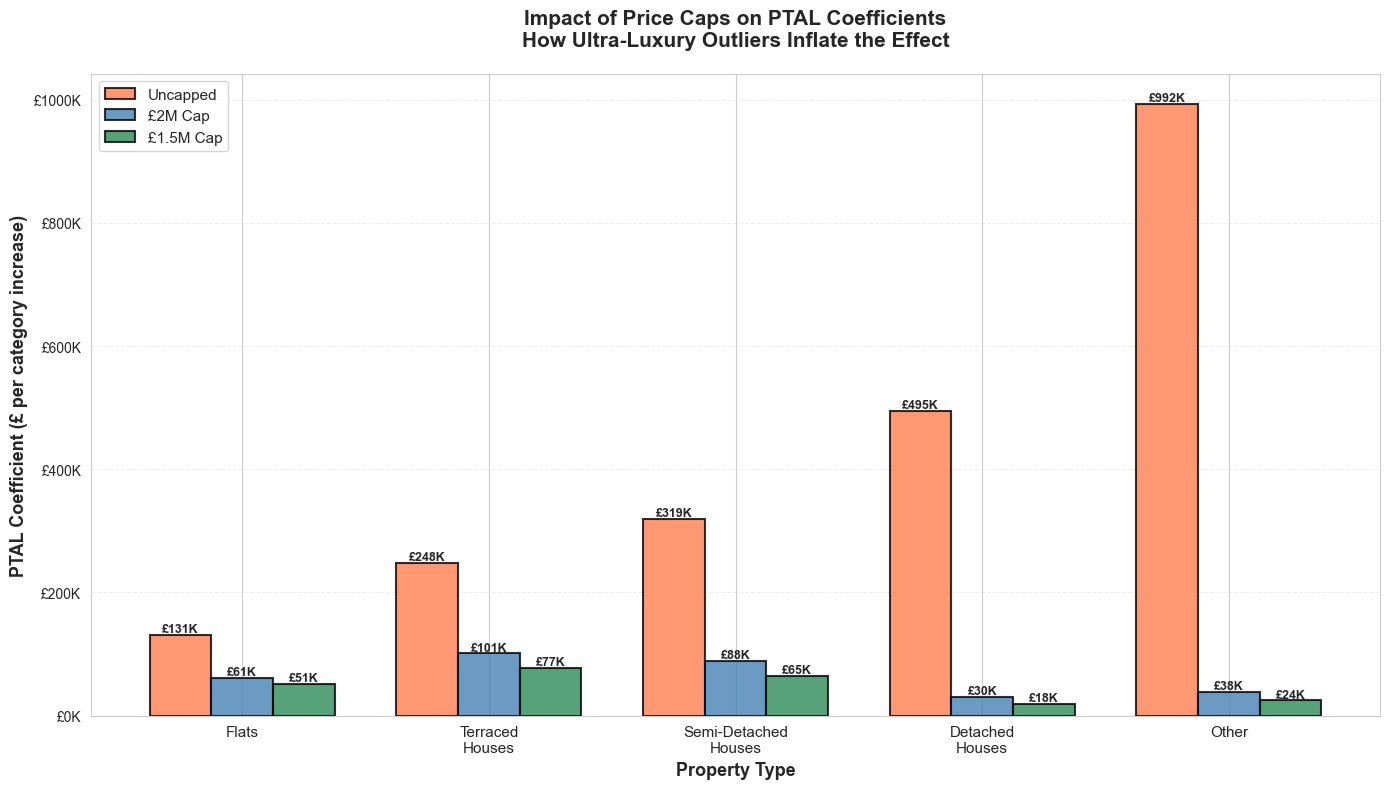


Creating Graph 2: Percentage Reduction...
✓ Saved: ptal_percentage_change.png


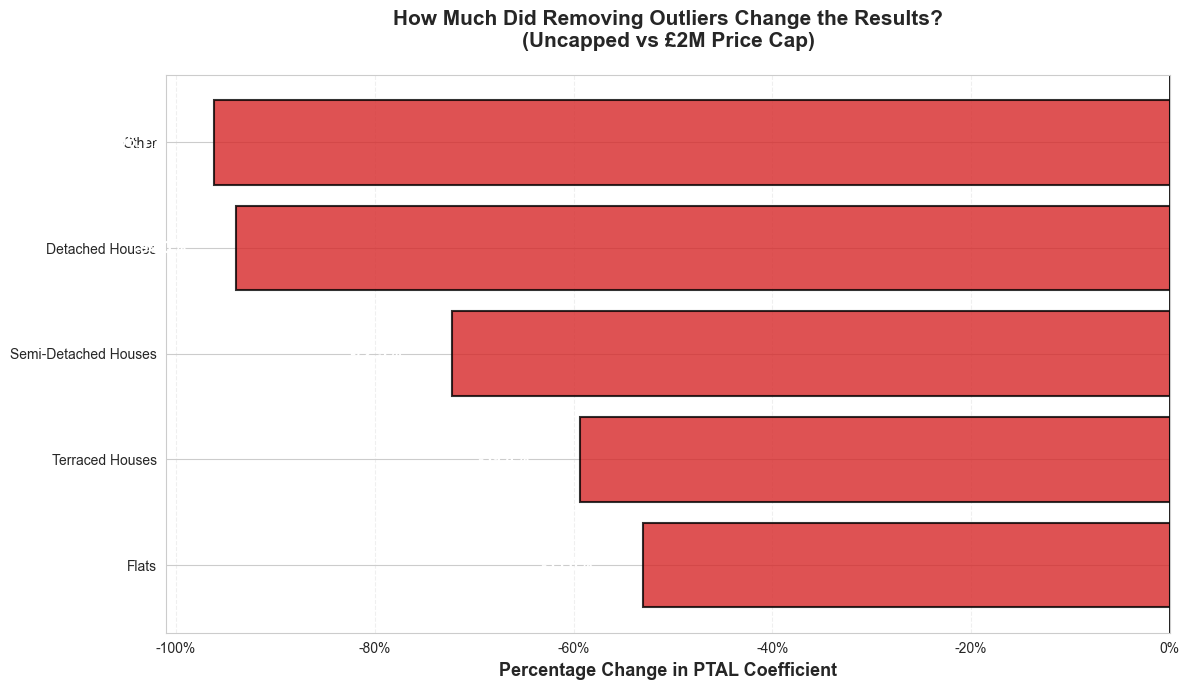


Creating Graph 3: R-squared Improvement...
✓ Saved: ptal_r2_comparison_caps.png


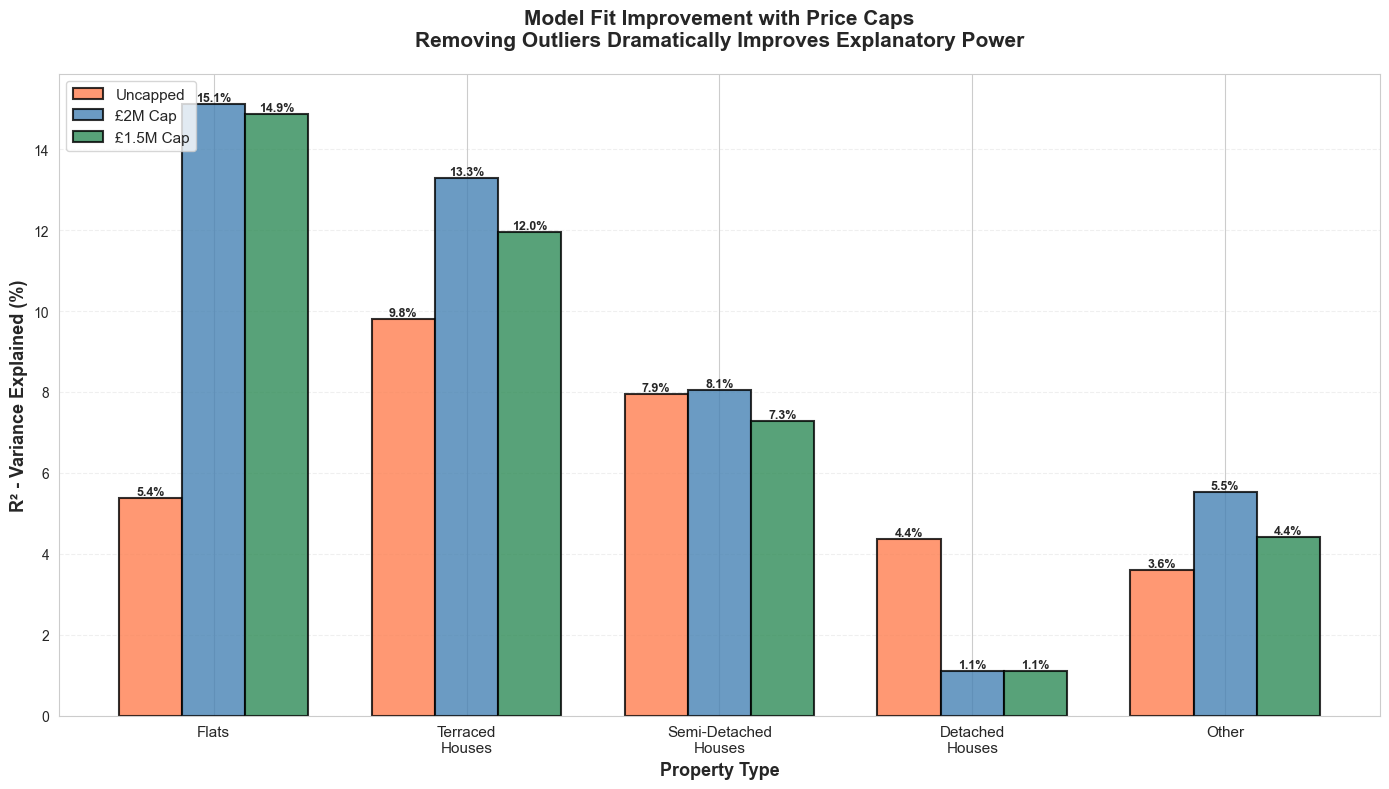


Creating Graph 4: Scatter Plot Comparison...
✓ Saved: ptal_scatter_comparison.png


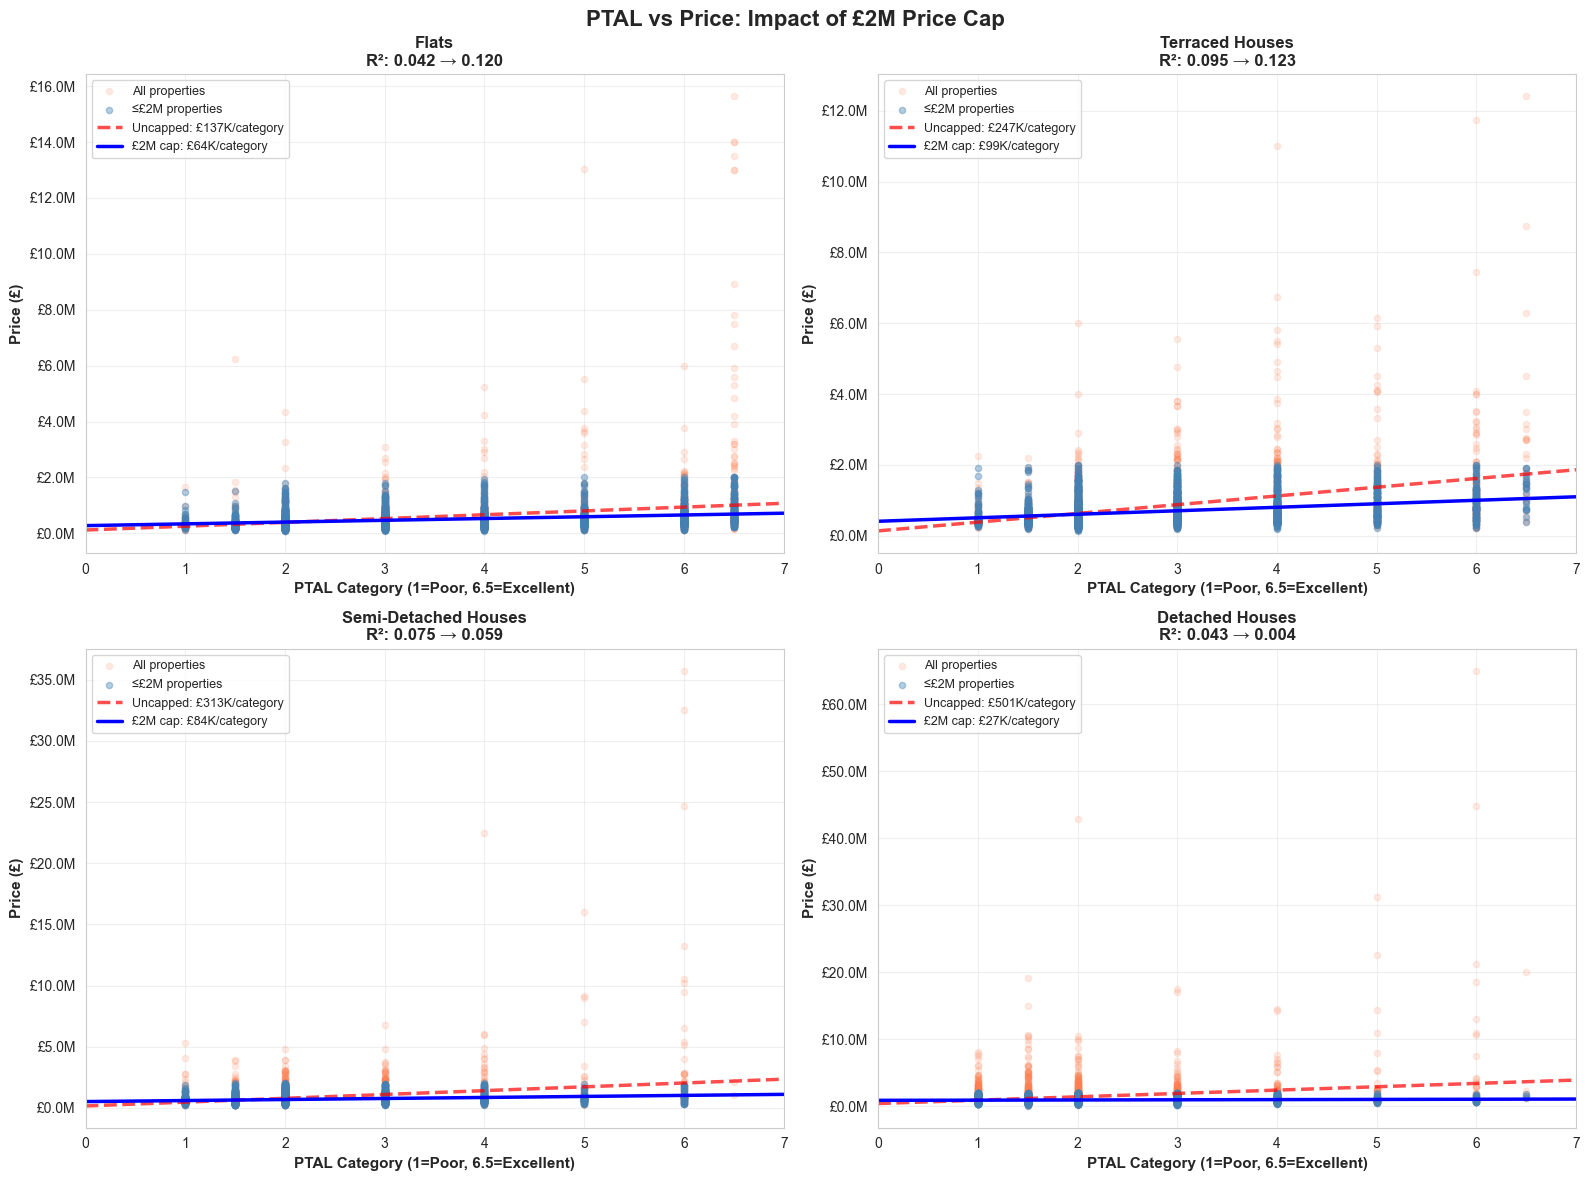


Creating Graph 5: Summary Table...
✓ Saved: ptal_summary_table_2m_cap.png


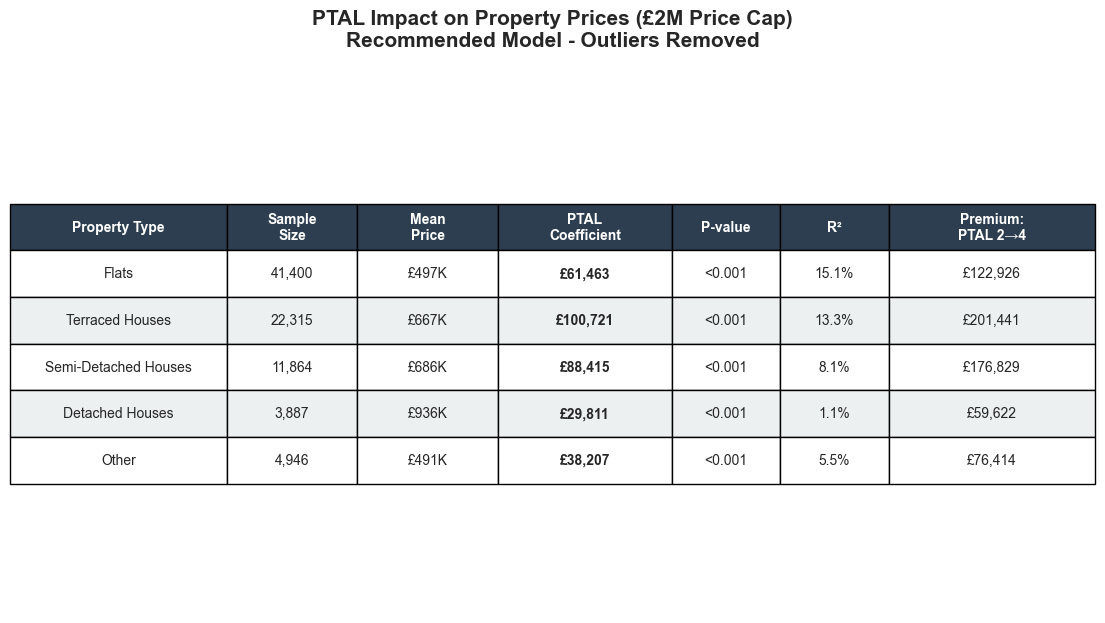


Creating Graph 6: Coefficient Trends...
✓ Saved: ptal_coefficient_trends.png


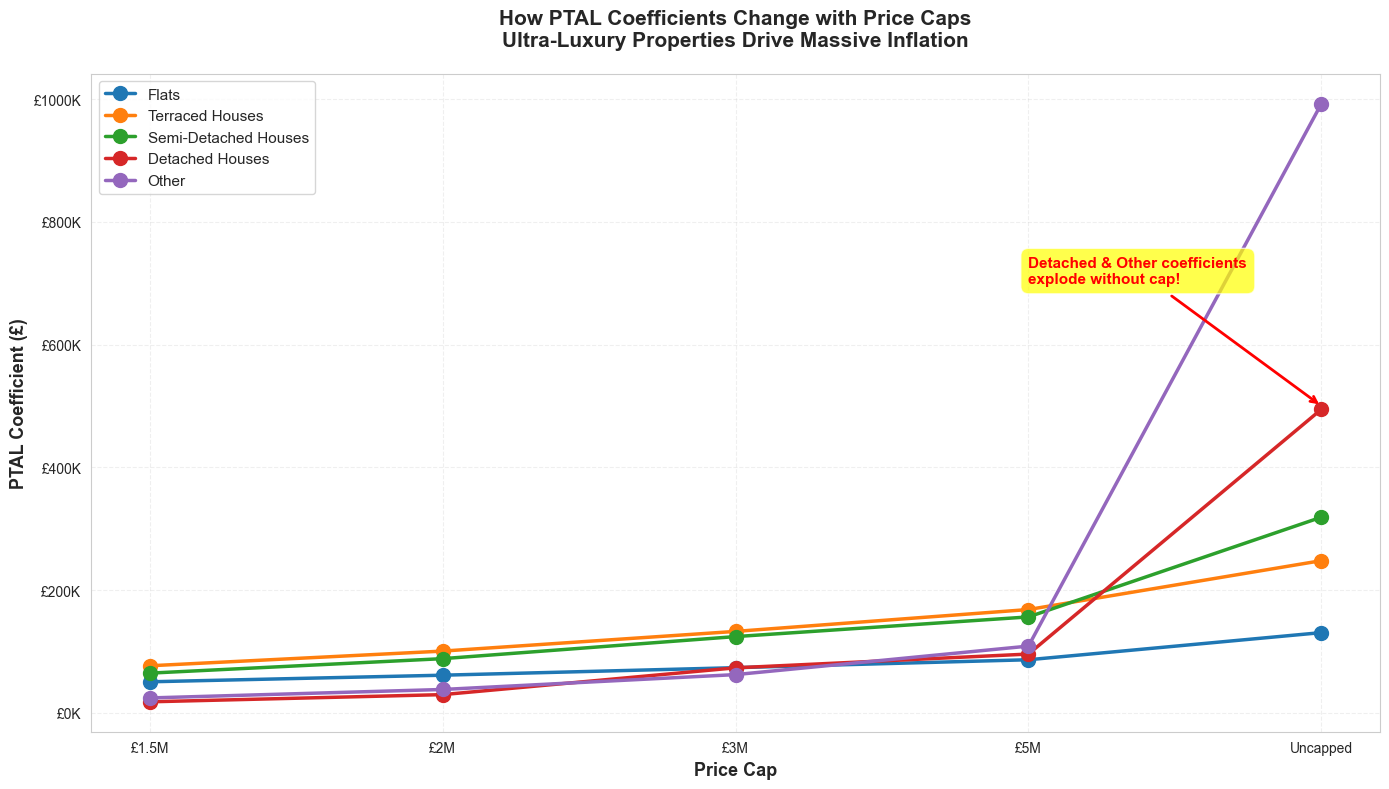


Creating Graph 7: Final Recommended Results...
✓ Saved: ptal_final_coefficients.png


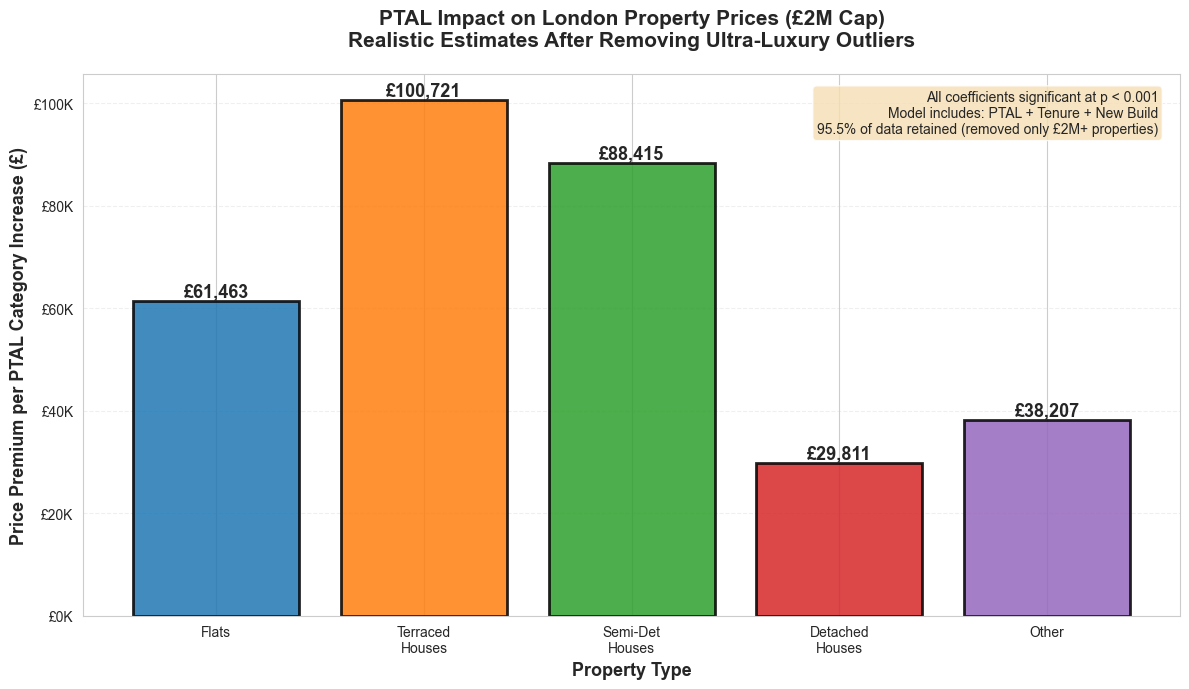


ALL VISUALIZATIONS COMPLETED!

Files saved:
1. ptal_coefficients_comparison_caps.png - Side-by-side cap comparison
2. ptal_percentage_change.png - % reduction from removing outliers
3. ptal_r2_comparison_caps.png - Model fit improvements
4. ptal_scatter_comparison.png - Before/after scatter plots
5. ptal_summary_table_2m_cap.png - Final results table
6. ptal_coefficient_trends.png - Trends across all caps
7. ptal_final_coefficients.png - Clean final results (recommended)



In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

print("="*70)
print("CREATING COMPREHENSIVE VISUALIZATIONS")
print("="*70)

# Property type mapping
property_type_map = {
    'F': 'Flats',
    'T': 'Terraced Houses',
    'S': 'Semi-Detached Houses',
    'D': 'Detached Houses',
    'O': 'Other'
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
prop_types = ['F', 'T', 'S', 'D', 'O']

# Data for comparisons (from your analysis)
# Uncapped results
uncapped_coefs = {
    'Flats': 130836.06,
    'Terraced Houses': 248055.57,
    'Semi-Detached Houses': 318842.43,
    'Detached Houses': 494632.64,
    'Other': 992373.09
}
uncapped_r2 = {
    'Flats': 0.0539,
    'Terraced Houses': 0.0980,
    'Semi-Detached Houses': 0.0794,
    'Detached Houses': 0.0437,
    'Other': 0.0361
}

# £2M cap results
cap_2m_coefs = {
    'Flats': 61463.10,
    'Terraced Houses': 100720.65,
    'Semi-Detached Houses': 88414.51,
    'Detached Houses': 29810.94,
    'Other': 38206.89
}
cap_2m_r2 = {
    'Flats': 0.1511,
    'Terraced Houses': 0.1328,
    'Semi-Detached Houses': 0.0806,
    'Detached Houses': 0.0111,
    'Other': 0.0553
}

# £1.5M cap results
cap_1_5m_coefs = {
    'Flats': 50722.91,
    'Terraced Houses': 76802.81,
    'Semi-Detached Houses': 64807.46,
    'Detached Houses': 18111.24,
    'Other': 24408.09
}
cap_1_5m_r2 = {
    'Flats': 0.1486,
    'Terraced Houses': 0.1196,
    'Semi-Detached Houses': 0.0728,
    'Detached Houses': 0.0109,
    'Other': 0.0442
}

# Sample sizes
sample_sizes = {
    'Flats': 41400,
    'Terraced Houses': 22315,
    'Semi-Detached Houses': 11864,
    'Detached Houses': 3887,
    'Other': 4946
}

# ============================================================================
# GRAPH 1: Coefficient Comparison - Uncapped vs Capped (Side by Side)
# ============================================================================
print("\nCreating Graph 1: Coefficient Comparison...")

fig, ax = plt.subplots(figsize=(14, 8))

prop_names = list(uncapped_coefs.keys())
x = np.arange(len(prop_names))
width = 0.25

bars1 = ax.bar(x - width, [uncapped_coefs[p] for p in prop_names], 
               width, label='Uncapped', color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, [cap_2m_coefs[p] for p in prop_names], 
               width, label='£2M Cap', color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + width, [cap_1_5m_coefs[p] for p in prop_names], 
               width, label='£1.5M Cap', color='seagreen', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'£{height/1000:.0f}K',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('PTAL Coefficient (£ per category increase)', fontsize=13, fontweight='bold')
ax.set_xlabel('Property Type', fontsize=13, fontweight='bold')
ax.set_title('Impact of Price Caps on PTAL Coefficients\nHow Ultra-Luxury Outliers Inflate the Effect', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([p.replace(' Houses', '\nHouses') for p in prop_names], fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ptal_coefficients_comparison_caps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_coefficients_comparison_caps.png")
plt.show()

# ============================================================================
# GRAPH 2: Percentage Change from Uncapped to £2M Cap
# ============================================================================
print("\nCreating Graph 2: Percentage Reduction...")

fig, ax = plt.subplots(figsize=(12, 7))

pct_changes = [(cap_2m_coefs[p] - uncapped_coefs[p]) / uncapped_coefs[p] * 100 
               for p in prop_names]

bars = ax.barh(prop_names, pct_changes, color=['#d62728' if x < 0 else '#2ca02c' for x in pct_changes],
               alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, pct in zip(bars, pct_changes):
    width = bar.get_width()
    ax.text(width - 5 if width < 0 else width + 1, bar.get_y() + bar.get_height()/2.,
            f'{pct:.1f}%',
            ha='right' if width < 0 else 'left', va='center', 
            fontsize=12, fontweight='bold', color='white' if width < -50 else 'black')

ax.axvline(x=0, color='black', linewidth=2, linestyle='-')
ax.set_xlabel('Percentage Change in PTAL Coefficient', fontsize=13, fontweight='bold')
ax.set_title('How Much Did Removing Outliers Change the Results?\n(Uncapped vs £2M Price Cap)', 
             fontsize=15, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ptal_percentage_change.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_percentage_change.png")
plt.show()

# ============================================================================
# GRAPH 3: R-squared Improvement Comparison
# ============================================================================
print("\nCreating Graph 3: R-squared Improvement...")

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(prop_names))
width = 0.25

bars1 = ax.bar(x - width, [uncapped_r2[p]*100 for p in prop_names], 
               width, label='Uncapped', color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, [cap_2m_r2[p]*100 for p in prop_names], 
               width, label='£2M Cap', color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + width, [cap_1_5m_r2[p]*100 for p in prop_names], 
               width, label='£1.5M Cap', color='seagreen', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('R² - Variance Explained (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Property Type', fontsize=13, fontweight='bold')
ax.set_title('Model Fit Improvement with Price Caps\nRemoving Outliers Dramatically Improves Explanatory Power', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([p.replace(' Houses', '\nHouses') for p in prop_names], fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ptal_r2_comparison_caps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_r2_comparison_caps.png")
plt.show()

# ============================================================================
# GRAPH 4: Scatter Plots - Uncapped vs £2M Cap (2x2 grid for main types)
# ============================================================================
print("\nCreating Graph 4: Scatter Plot Comparison...")

# Prepare PTAL_numeric
ptal_category_map = {
    '0': 0, '1a': 1, '1b': 1.5, '2': 2, '3': 3,
    '4': 4, '5': 5, '6a': 6, '6b': 6.5
}
df_analysis['PTAL_numeric'] = df_analysis['MEAN_PTAL_2023'].map(ptal_category_map)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PTAL vs Price: Impact of £2M Price Cap', fontsize=16, fontweight='bold')

main_types = [('F', 'Flats'), ('T', 'Terraced Houses'), 
              ('S', 'Semi-Detached Houses'), ('D', 'Detached Houses')]

for idx, (prop_type, prop_name) in enumerate(main_types):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Get data
    df_type = df_analysis[df_analysis['PropertyType'] == prop_type].copy()
    df_type = df_type.dropna(subset=['PTAL_numeric'])
    
    # Plot uncapped (all data) - lighter color
    sample_size = min(3000, len(df_type))
    df_sample = df_type.sample(n=sample_size, random_state=42)
    ax.scatter(df_sample['PTAL_numeric'], df_sample['Price'], 
               alpha=0.15, s=20, color='coral', label='All properties')
    
    # Plot capped (<=2M) - darker color
    df_capped = df_type[df_type['Price'] <= 2_000_000]
    sample_size_capped = min(3000, len(df_capped))
    df_sample_capped = df_capped.sample(n=sample_size_capped, random_state=42)
    ax.scatter(df_sample_capped['PTAL_numeric'], df_sample_capped['Price'], 
               alpha=0.4, s=20, color='steelblue', label='≤£2M properties')
    
    # Add regression lines
    # Uncapped line
    slope_un, intercept_un, r_un, _, _ = stats.linregress(df_type['PTAL_numeric'], df_type['Price'])
    line_x = np.array([0, 7])
    ax.plot(line_x, slope_un * line_x + intercept_un, 
            'r--', linewidth=2.5, label=f'Uncapped: £{slope_un/1000:.0f}K/category', alpha=0.7)
    
    # Capped line
    slope_cap, intercept_cap, r_cap, _, _ = stats.linregress(df_capped['PTAL_numeric'], df_capped['Price'])
    ax.plot(line_x, slope_cap * line_x + intercept_cap, 
            'b-', linewidth=2.5, label=f'£2M cap: £{slope_cap/1000:.0f}K/category')
    
    # Formatting
    ax.set_xlabel('PTAL Category (1=Poor, 6.5=Excellent)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (£)', fontsize=11, fontweight='bold')
    ax.set_title(f'{prop_name}\nR²: {r_un**2:.3f} → {r_cap**2:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.1f}M'))
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 7)

plt.tight_layout()
plt.savefig('ptal_scatter_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_scatter_comparison.png")
plt.show()

# ============================================================================
# GRAPH 5: Summary Table - Recommended £2M Cap Results
# ============================================================================
print("\nCreating Graph 5: Summary Table...")

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Property Type', 'Sample\nSize', 'Mean\nPrice', 'PTAL\nCoefficient', 'P-value', 'R²', 'Premium:\nPTAL 2→4'],
]

for prop_name in prop_names:
    n = sample_sizes[prop_name]
    coef = cap_2m_coefs[prop_name]
    r2 = cap_2m_r2[prop_name]
    premium = coef * 2  # Moving 2 categories
    
    # Mean prices (approximate from your data)
    mean_prices = {
        'Flats': 497200,
        'Terraced Houses': 667307,
        'Semi-Detached Houses': 686245,
        'Detached Houses': 936372,
        'Other': 491321
    }
    
    table_data.append([
        prop_name,
        f'{n:,}',
        f'£{mean_prices[prop_name]/1000:.0f}K',
        f'£{coef:,.0f}',
        '<0.001',
        f'{r2*100:.1f}%',
        f'£{premium:,.0f}'
    ])

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.20, 0.12, 0.13, 0.16, 0.10, 0.10, 0.19])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.8)

# Style header row
for i in range(7):
    table[(0, i)].set_facecolor('#2c3e50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, 6):
    color = '#ecf0f1' if i % 2 == 0 else 'white'
    for j in range(7):
        table[(i, j)].set_facecolor(color)
        if j == 3:  # Highlight coefficient column
            table[(i, j)].set_text_props(weight='bold')

plt.title('PTAL Impact on Property Prices (£2M Price Cap)\nRecommended Model - Outliers Removed', 
          fontsize=15, fontweight='bold', pad=20)
plt.savefig('ptal_summary_table_2m_cap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_summary_table_2m_cap.png")
plt.show()

# ============================================================================
# GRAPH 6: Coefficient Progression Across All Price Caps
# ============================================================================
print("\nCreating Graph 6: Coefficient Trends...")

fig, ax = plt.subplots(figsize=(14, 8))

price_caps = [1.5, 2.0, 3.0, 5.0, np.inf]
price_cap_labels = ['£1.5M', '£2M', '£3M', '£5M', 'Uncapped']

# Data from your analysis
coef_data = {
    'Flats': [50722.91, 61463.10, 73714.60, 86632.92, 130836.06],
    'Terraced Houses': [76802.81, 100720.65, 132806.09, 168420.98, 248055.57],
    'Semi-Detached Houses': [64807.46, 88414.51, 124351.50, 156391.97, 318842.43],
    'Detached Houses': [18111.24, 29810.94, 73484.14, 95895.58, 494632.64],
    'Other': [24408.09, 38206.89, 62425.01, 108877.50, 992373.09]
}

for idx, (prop_name, coefs) in enumerate(coef_data.items()):
    ax.plot(price_cap_labels, coefs, marker='o', linewidth=2.5, 
            markersize=10, label=prop_name, color=colors[idx])

ax.set_ylabel('PTAL Coefficient (£)', fontsize=13, fontweight='bold')
ax.set_xlabel('Price Cap', fontsize=13, fontweight='bold')
ax.set_title('How PTAL Coefficients Change with Price Caps\nUltra-Luxury Properties Drive Massive Inflation', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1000:.0f}K'))
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add annotation
ax.annotate('Detached & Other coefficients\nexplode without cap!', 
            xy=(4, 500000), xytext=(3, 700000),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, fontweight='bold', color='red',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('ptal_coefficient_trends.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_coefficient_trends.png")
plt.show()

# ============================================================================
# GRAPH 7: Recommended Model - Clean Coefficient Chart
# ============================================================================
print("\nCreating Graph 7: Final Recommended Results...")

fig, ax = plt.subplots(figsize=(12, 7))

prop_names_short = ['Flats', 'Terraced\nHouses', 'Semi-Det\nHouses', 'Detached\nHouses', 'Other']
coefs_2m = [cap_2m_coefs[p] for p in prop_names]

bars = ax.bar(prop_names_short, coefs_2m, color=colors, 
              alpha=0.85, edgecolor='black', linewidth=2)

# Add value labels
for bar, coef in zip(bars, coefs_2m):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'£{coef:,.0f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Price Premium per PTAL Category Increase (£)', fontsize=13, fontweight='bold')
ax.set_xlabel('Property Type', fontsize=13, fontweight='bold')
ax.set_title('PTAL Impact on London Property Prices (£2M Cap)\nRealistic Estimates After Removing Ultra-Luxury Outliers', 
             fontsize=15, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add note
ax.text(0.98, 0.97, 'All coefficients significant at p < 0.001\nModel includes: PTAL + Tenure + New Build\n95.5% of data retained (removed only £2M+ properties)',
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('ptal_final_coefficients.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ptal_final_coefficients.png")
plt.show()

print("\n" + "="*70)
print("ALL VISUALIZATIONS COMPLETED!")
print("="*70)
print("""
Files saved:
1. ptal_coefficients_comparison_caps.png - Side-by-side cap comparison
2. ptal_percentage_change.png - % reduction from removing outliers
3. ptal_r2_comparison_caps.png - Model fit improvements
4. ptal_scatter_comparison.png - Before/after scatter plots
5. ptal_summary_table_2m_cap.png - Final results table
6. ptal_coefficient_trends.png - Trends across all caps
7. ptal_final_coefficients.png - Clean final results (recommended)
""")